# Głębokie Uczenie w Praktyce
## Laboratorium 6
### Mateusz Horczak

In [13]:
import os
import matplotlib.pyplot as plt
from tensorflow.keras import models, layers, optimizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications import VGG16
import numpy as np

### Komórka diagnostyczna – ustawienie ścieżek (uruchom jako pierwszą!)

In [14]:
print("=== DIAGNOSTYKA ŚCIEŻEK ===")
print("Bieżący katalog roboczy:", os.getcwd())
print("Zawartość bieżącego katalogu:", os.listdir('.'))

base_dir = 'train-test-valid'

train_dir      = os.path.join(base_dir, 'train')
validation_dir = os.path.join(base_dir, 'validation')
test_dir       = os.path.join(base_dir, 'test')

print("\nSprawdzanie folderów danych:")
print("train_dir exists     :", os.path.exists(train_dir))
print("validation_dir exists:", os.path.exists(validation_dir))
print("test_dir exists      :", os.path.exists(test_dir))

=== DIAGNOSTYKA ŚCIEŻEK ===
Bieżący katalog roboczy: /home/mateusz/PycharmProjects/glebokie_uczenie_w_praktyce/lab6
Zawartość bieżącego katalogu: ['train-test-valid', 'lab6.ipynb']

Sprawdzanie folderów danych:
train_dir exists     : True
validation_dir exists: True
test_dir exists      : True


#### Ćwiczenie 1

In [15]:
conv_base = VGG16(weights='imagenet',
                  include_top=False,
                  input_shape=(150, 150, 3))

conv_base.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 150, 150, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 150, 150, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 75, 75, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 75, 75, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 75, 75, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 37, 37, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 37, 37, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 37, 37, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 37, 37, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 18, 18, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 18, 18, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 18, 18, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 18, 18, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 9, 9, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 4, 4, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 14,714,688 (56.13 MB)

 Non-trainable params: 0 (0.00 B)

#### Ćwiczenie 2

In [16]:
datagen = ImageDataGenerator(rescale=1./255)
batch_size = 20

def extract_features(directory, sample_count):
    features = np.zeros(shape=(sample_count, 4, 4, 512))
    labels = np.zeros(shape=(sample_count))
    generator = datagen.flow_from_directory(
        directory,
        target_size=(150, 150),
        batch_size=batch_size,
        class_mode='binary')

    i = 0
    for inputs_batch, labels_batch in generator:
        features_batch = conv_base.predict(inputs_batch, verbose=0)
        features[i * batch_size : (i + 1) * batch_size] = features_batch
        labels[i * batch_size : (i + 1) * batch_size] = labels_batch
        i += 1
        if i * batch_size >= sample_count:
            break
    return features, labels

train_features, train_labels = extract_features(train_dir, 2000)
validation_features, validation_labels = extract_features(validation_dir, 1000)
test_features, test_labels = extract_features(test_dir, 1000)

train_features = np.reshape(train_features, (2000, 4 * 4 * 512))
validation_features = np.reshape(validation_features, (1000, 4 * 4 * 512))
test_features = np.reshape(test_features, (1000, 4 * 4 * 512))

print("Kształty po reshape:", train_features.shape, validation_features.shape)

Found 2000 images belonging to 2 classes.
Found 1000 images belonging to 2 classes.
Found 1000 images belonging to 2 classes.
Kształty po reshape: (2000, 8192) (1000, 8192)


#### Ćwiczenie 3

In [17]:
model = models.Sequential()
model.add(layers.Dense(256, activation='relu', input_dim=4 * 4 * 512))
model.add(layers.Dropout(0.5))
model.add(layers.Dense(1, activation='sigmoid'))

model.compile(optimizer=optimizers.RMSprop(learning_rate=2e-5),
              loss='binary_crossentropy',
              metrics=['acc'])

history = model.fit(train_features, train_labels,
                    epochs=30,
                    batch_size=20,
                    validation_data=(validation_features, validation_labels))

/home/mateusz/PycharmProjects/glebokie_uczenie_w_praktyce/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - acc: 0.6850 - loss: 0.5792 - val_acc: 0.8420 - val_loss: 0.4232
Epoch 2/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - acc: 0.8200 - loss: 0.4146 - val_acc: 0.8640 - val_loss: 0.3532
Epoch 3/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - acc: 0.8435 - loss: 0.3554 - val_acc: 0.8710 - val_loss: 0.3245
Epoch 4/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - acc: 0.8695 - loss: 0.3199 - val_acc: 0.8790 - val_loss: 0.2991
Epoch 5/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - acc: 0.8855 - loss: 0.2842 - val_acc: 0.8900 - val_loss: 0.2820
Epoch 6/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - acc: 0.8940 - loss: 0.2684 - val_acc: 0.8950 - val_loss: 0.2741
Epoch 7/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - acc: 0.8990 - loss: 0.2458 - val_acc: 0.8900 - val_loss: 0.2674
Epoch 8/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - acc: 0.9105 - loss: 0.2389 - val_acc: 0.8900 - val_loss: 0.2633
Epoch 9/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/

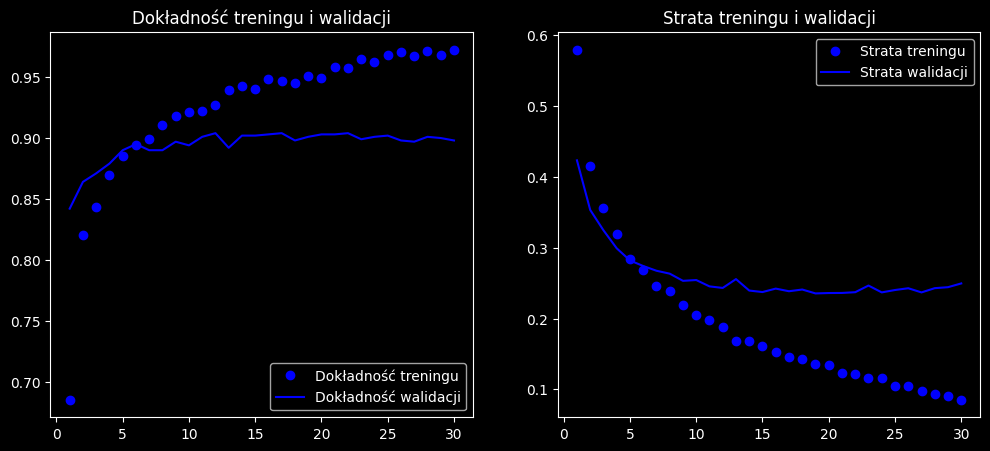

In [18]:
acc = history.history['acc']
val_acc = history.history['val_acc']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1, len(acc) + 1)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs, acc, 'bo', label='Dokładność treningu')
plt.plot(epochs, val_acc, 'b', label='Dokładność walidacji')
plt.title('Dokładność treningu i walidacji')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs, loss, 'bo', label='Strata treningu')
plt.plot(epochs, val_loss, 'b', label='Strata walidacji')
plt.title('Strata treningu i walidacji')
plt.legend()
plt.show()

#### Część 2 Sprawozdania

#### Ćwiczenie 1 – Model z poprzedniego zadania (z augmentacją)

In [19]:
model = models.Sequential()
model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(150, 150, 3)))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(128, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(128, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Flatten())
model.add(layers.Dense(512, activation='relu'))
model.add(layers.Dense(1, activation='sigmoid'))

model.compile(loss='binary_crossentropy',
              optimizer=optimizers.RMSprop(learning_rate=1e-4),
              metrics=['acc'])
model.summary()

/home/mateusz/PycharmProjects/glebokie_uczenie_w_praktyce/.venv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 15, 15, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │     3,211,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,453,121 (13.17 MB)

 Trainable params: 3,453,121 (13.17 MB)

 Non-trainable params: 0 (0.00 B)

#### Ćwiczenie 2

Kształt obrazu wejściowego: (1, 150, 150, 3)


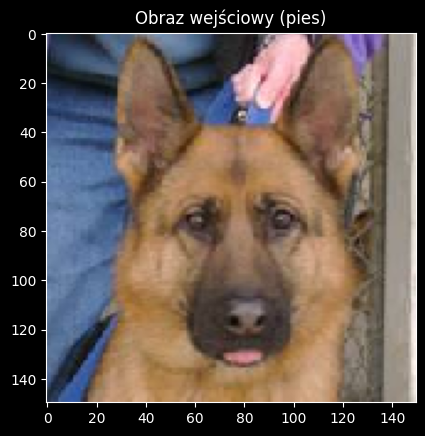

In [20]:
img_path = os.path.join(test_dir, 'dogs/dog.1513.jpg')

img = image.load_img(img_path, target_size=(150, 150))
img_tensor = image.img_to_array(img)
img_tensor = np.expand_dims(img_tensor, axis=0)
img_tensor /= 255.

print('Kształt obrazu wejściowego:', img_tensor.shape)

plt.imshow(img_tensor[0])
plt.title('Obraz wejściowy (pies)')
plt.show()

In [24]:
layer_outputs = [layer.output for layer in model.layers[:8]]
activation_model = models.Model(inputs=model.layers[0].input, outputs=layer_outputs)

activation_model.summary()

Model: "functional_16"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_5       │ (None, 150, 150,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 148, 148,  │        896 │ input_layer_5[0]… │
│                     │ 32)               │            │ input_layer_5[0]… │
│                     │                   │            │ input_layer_5[0]… │
│                     │                   │            │ input_layer_5[0]… │
│                     │                   │            │ input_layer_5[0]… │
│                     │                   │            │ input_layer_5[0]… │
│                     │                   │            │ input_layer_5[0]… │
│                     │                   │            │ input_layer_5[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 74, 74,    │          0 │ conv2d[1][0],     │
│ (MaxPooling2D)      │ 32)               │            │ conv2d[2][0],     │
│                     │                   │            │ conv2d[3][0],     │
│                     │                   │            │ conv2d[4][0],     │
│                     │                   │            │ conv2d[5][0],     │
│                     │                   │            │ conv2d[6][0],     │
│                     │                   │            │ conv2d[7][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 72, 72,    │     18,496 │ max_pooling2d[1]… │
│                     │ 64)               │            │ max_pooling2d[2]… │
│                     │                   │            │ max_pooling2d[3]… │
│                     │                   │            │ max_pooling2d[4]… │
│                     │                   │            │ max_pooling2d[5]… │
│                     │                   │            │ max_pooling2d[6]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 36, 36,    │          0 │ conv2d_1[1][0],   │
│ (MaxPooling2D)      │ 64)               │            │ conv2d_1[2][0],   │
│                     │                   │            │ conv2d_1[3][0],   │
│                     │                   │            │ conv2d_1[4][0],   │
│                     │                   │            │ conv2d_1[5][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 34, 34,    │     73,856 │ max_pooling2d_1[… │
│                     │ 128)              │            │ max_pooling2d_1[… │
│                     │                   │            │ max_pooling2d_1[… │
│                     │                   │            │ max_pooling2d_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 17, 17,    │          0 │ conv2d_2[1][0],   │
│ (MaxPooling2D)      │ 128)              │            │ conv2d_2[2][0],   │
│                     │                   │            │ conv2d_2[3][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 15, 15,    │    147,584 │ max_pooling2d_2[… │
│                     │ 128)              │            │ max_pooling2d_2[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 7, 7, 128) │          0 │ conv2d_3[1][0]    │
│ (MaxPooling2D)      │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 240,832 (940.75 KB)

 Trainable params: 240,832 (940.75 KB)

 Non-trainable params: 0 (0.00 B)

#### Ćwiczenie 4 i 5

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 337ms/step
Shape warstwy 1: (1, 148, 148, 32)


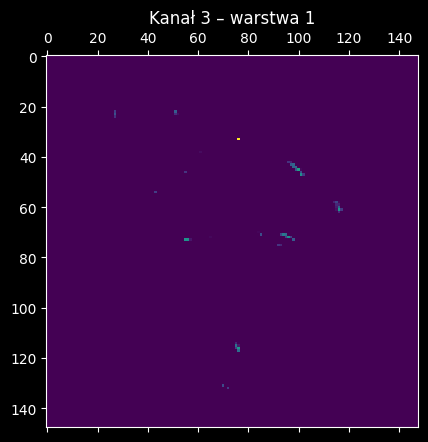

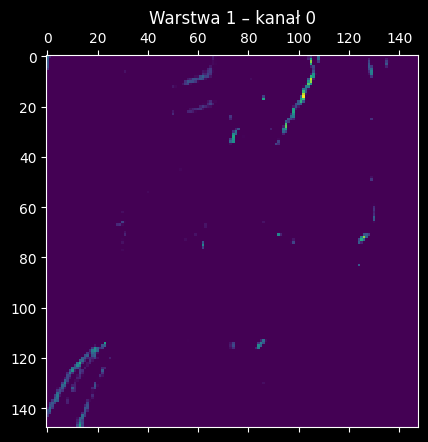

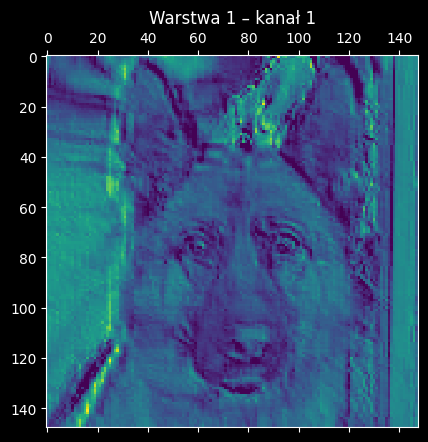

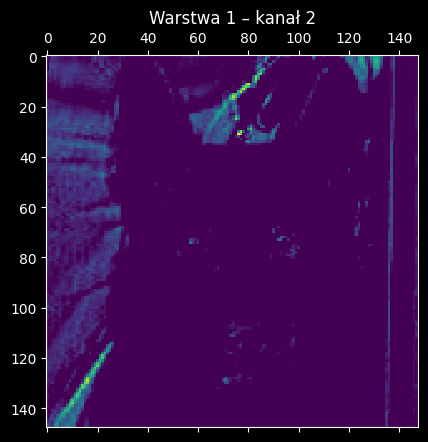

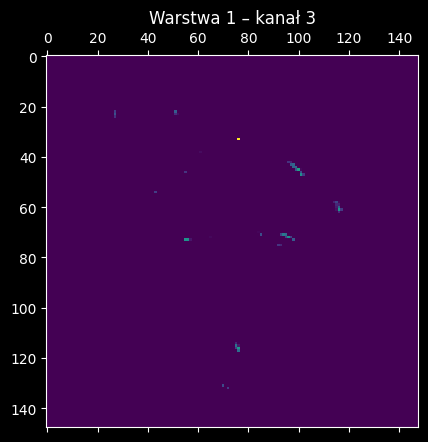

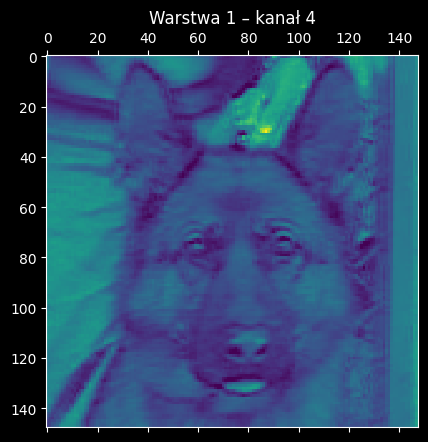

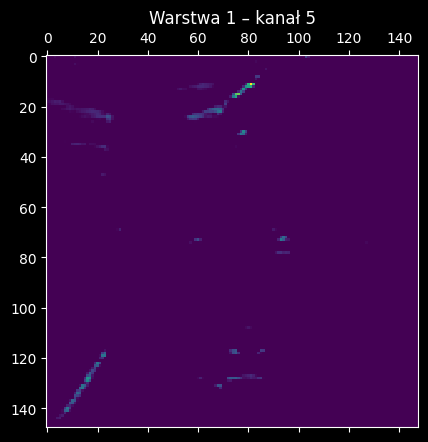

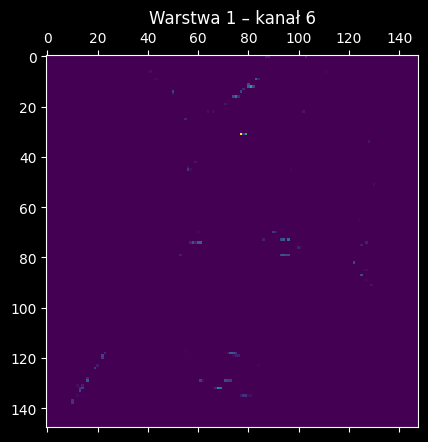

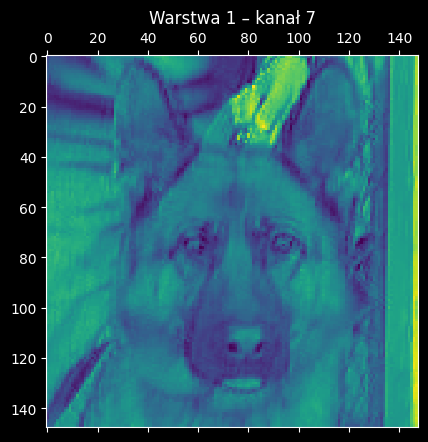

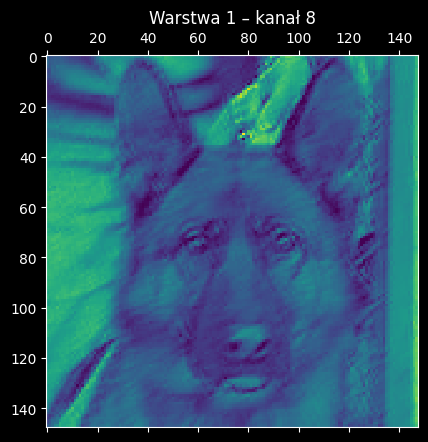

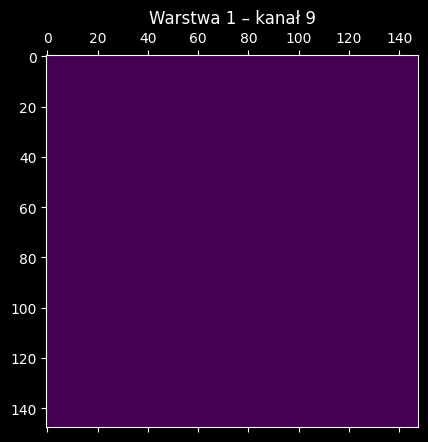

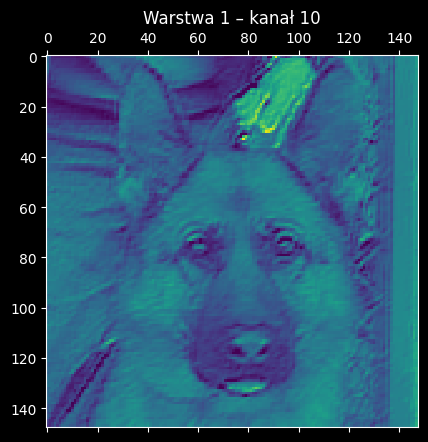

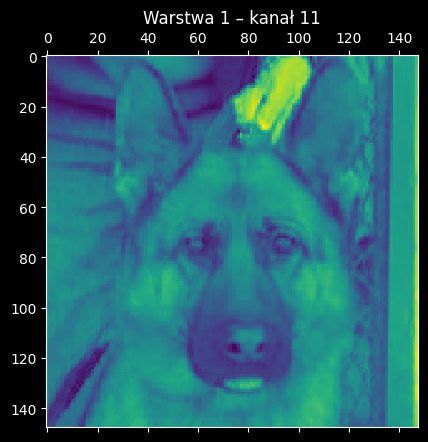

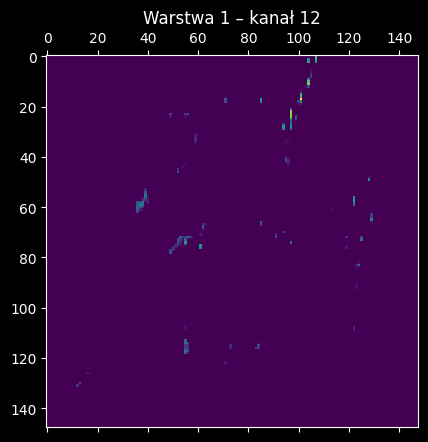

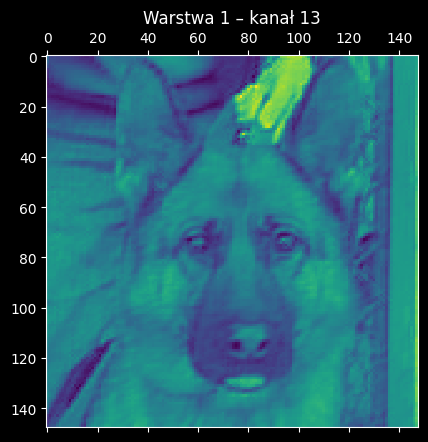

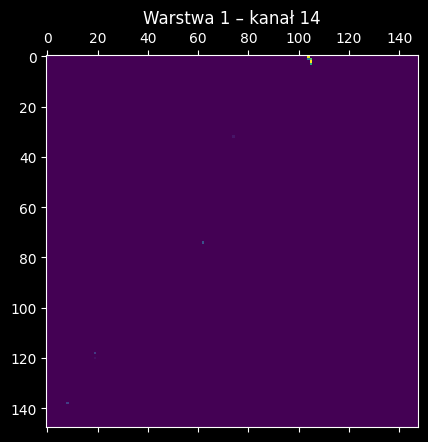

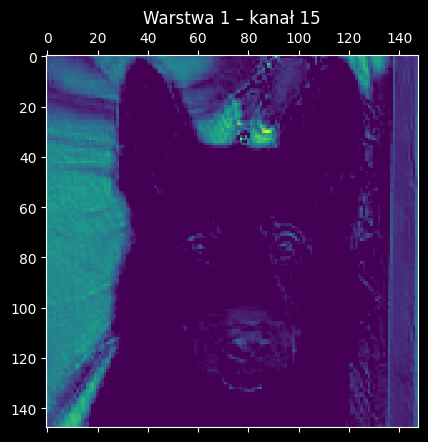

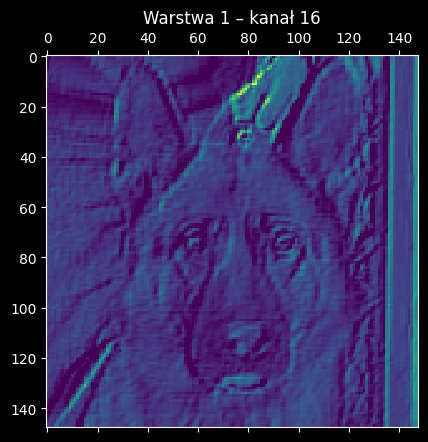

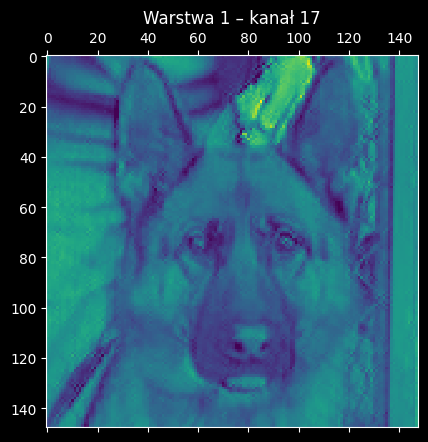

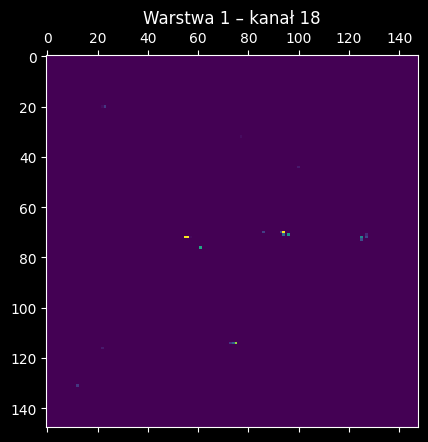

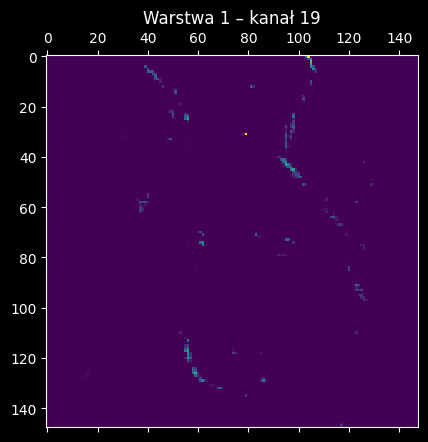

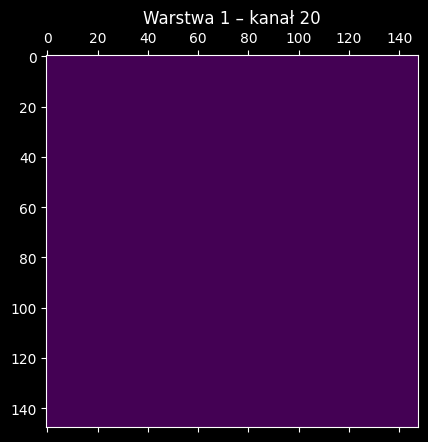

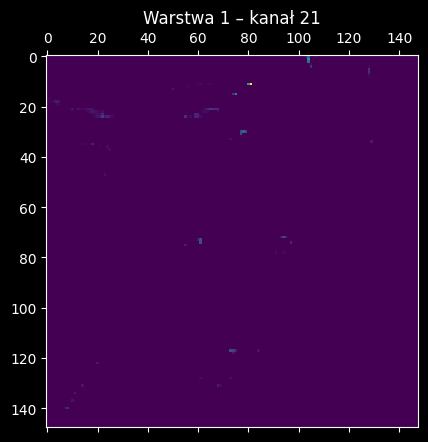

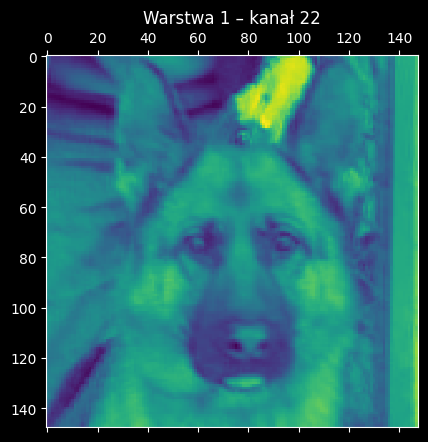

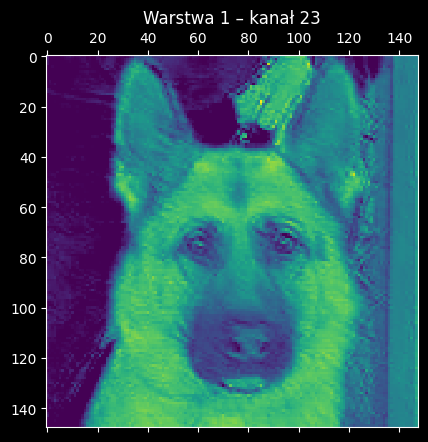

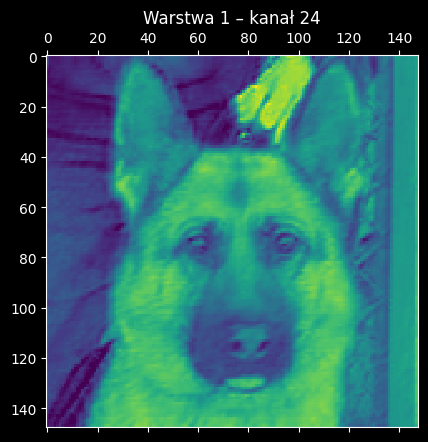

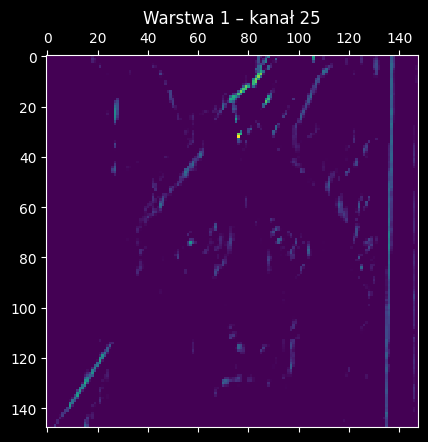

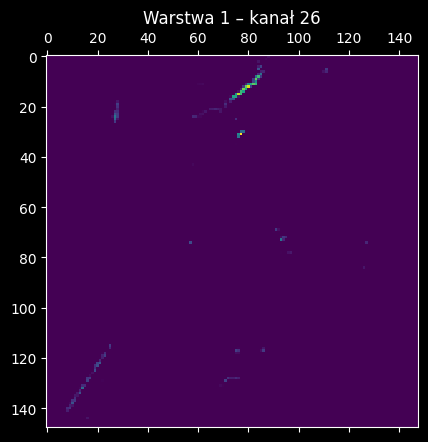

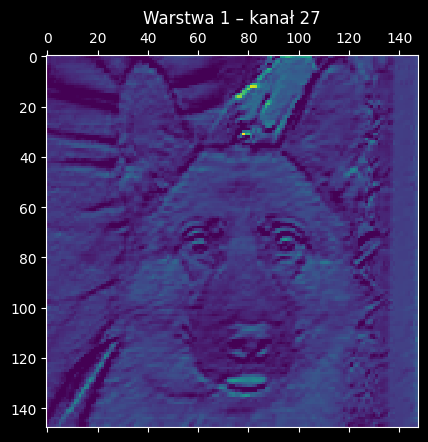

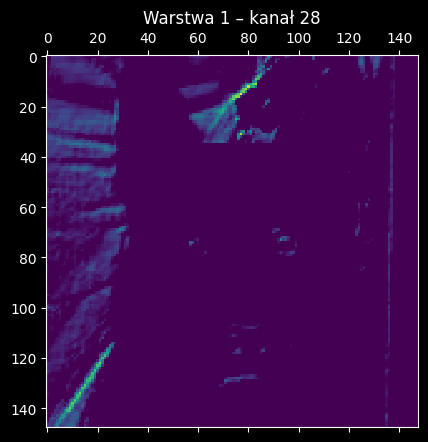

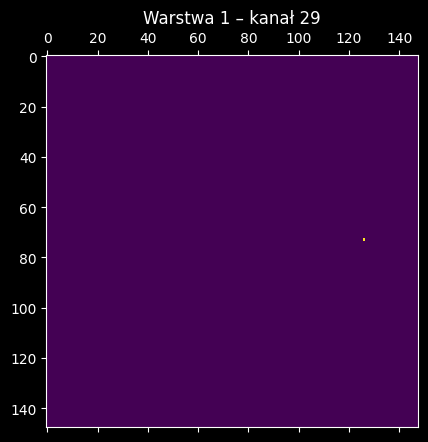

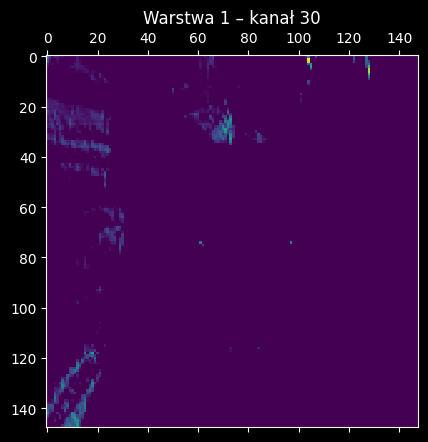

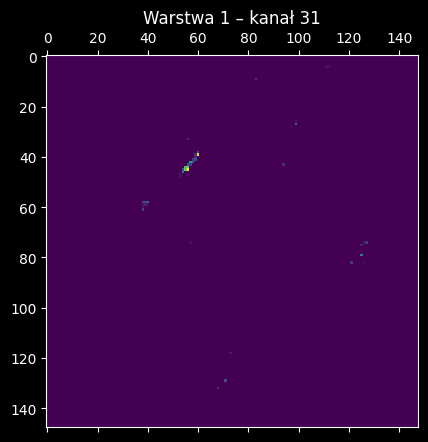

In [25]:
activations = activation_model.predict(img_tensor)

first_layer_activation = activations[0]
print('Shape warstwy 1:', first_layer_activation.shape)

plt.matshow(first_layer_activation[0, :, :, 3], cmap='viridis')
plt.title('Kanał 3 – warstwa 1')
plt.show()

for i in range(32):
    plt.matshow(first_layer_activation[0, :, :, i], cmap='viridis')
    plt.title(f'Warstwa 1 – kanał {i}')
    plt.show()

Shape conv1: (1, 74, 74, 32)


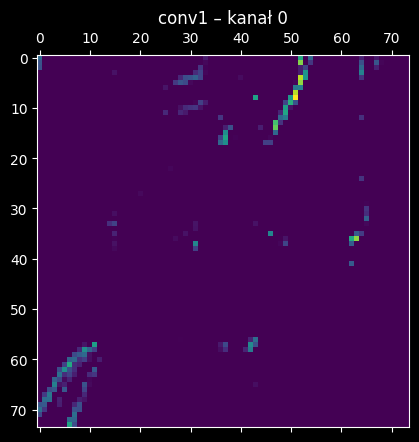

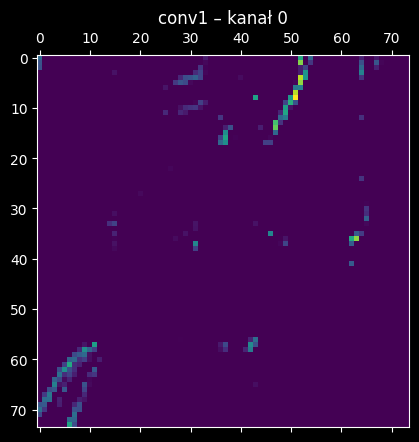

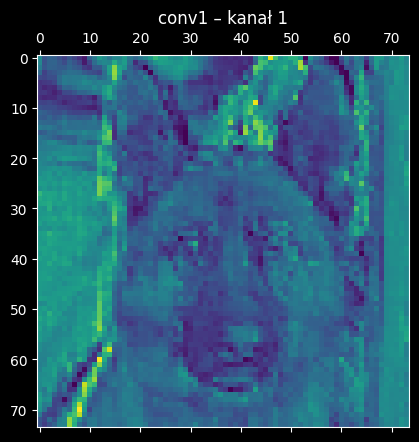

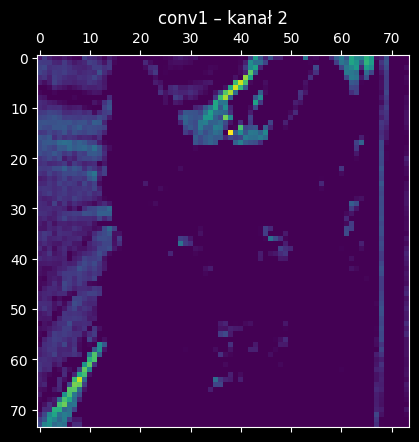

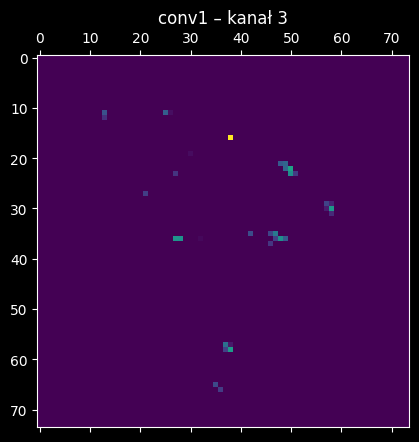

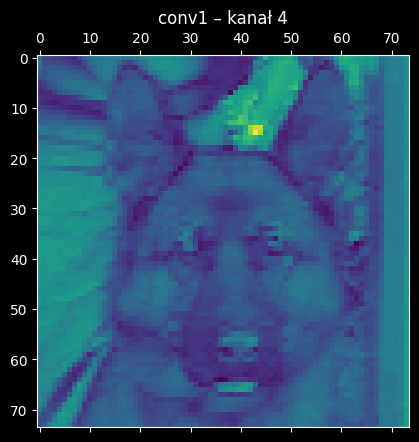

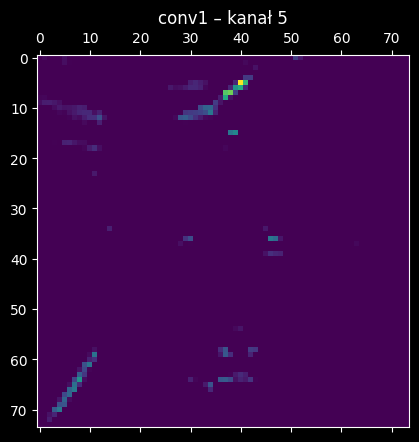

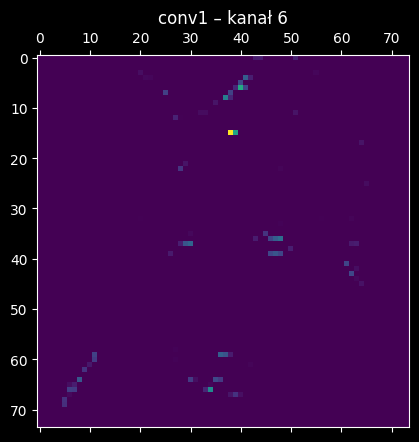

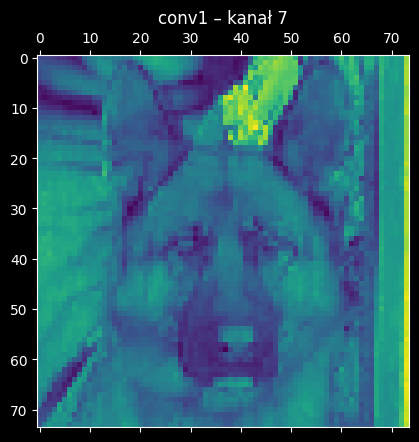

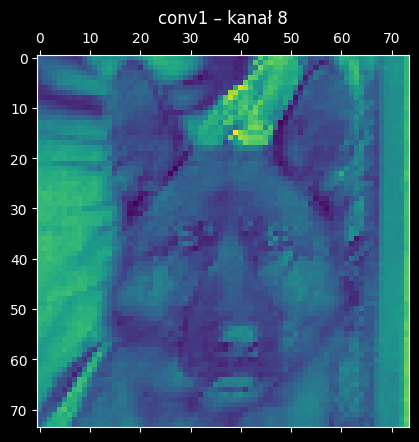

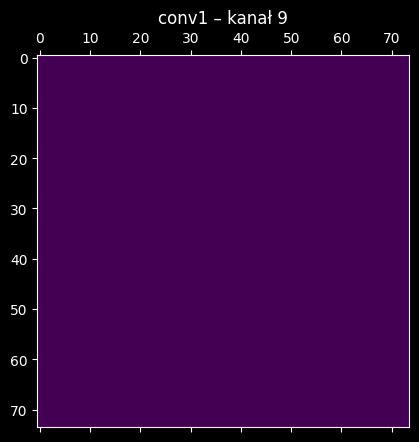

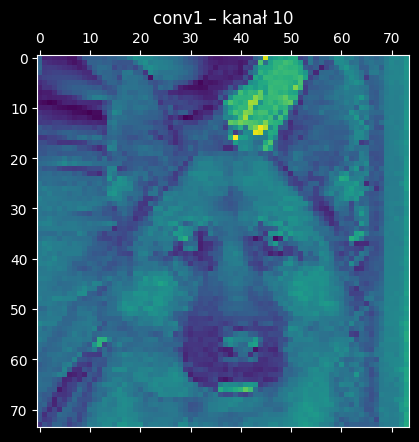

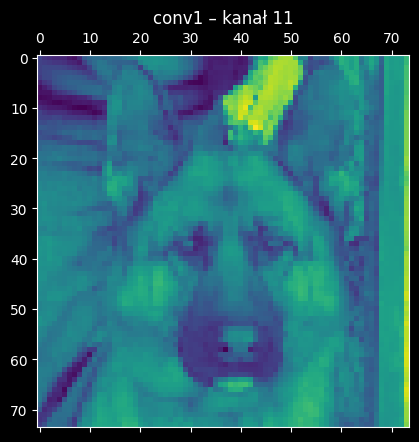

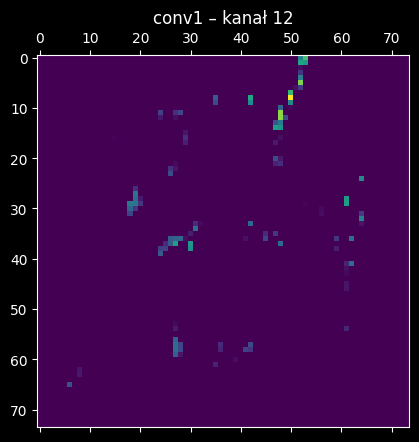

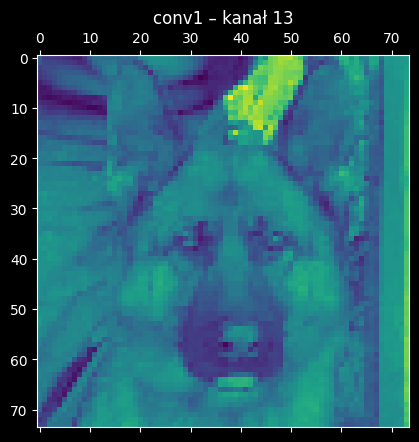

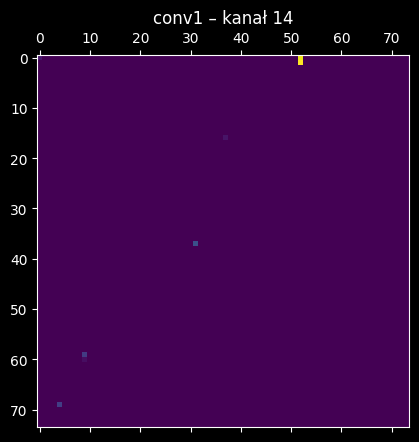

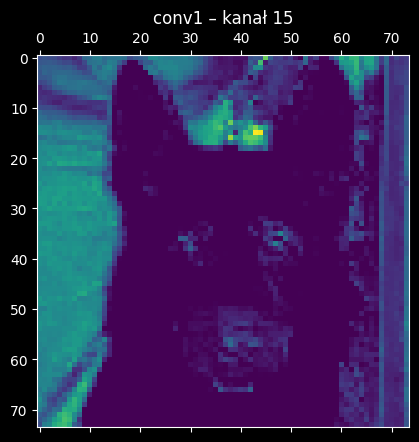

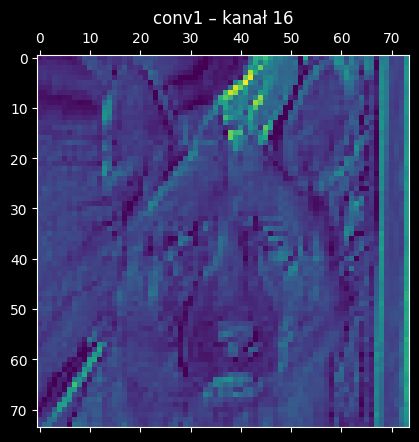

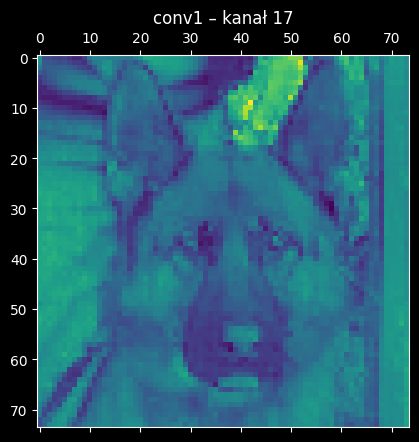

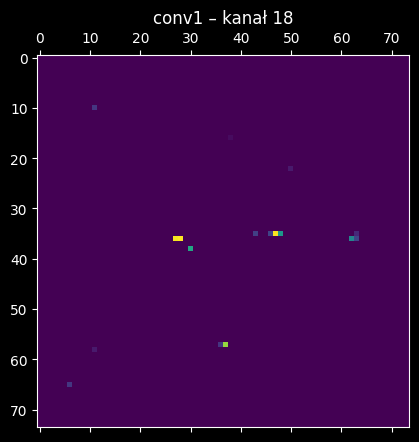

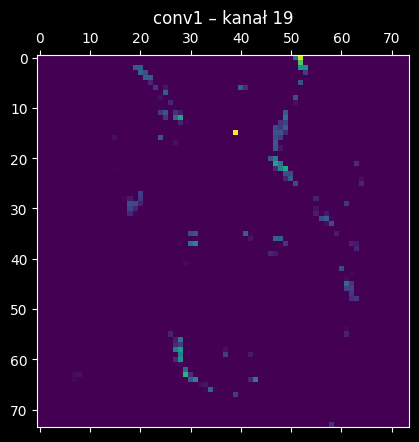

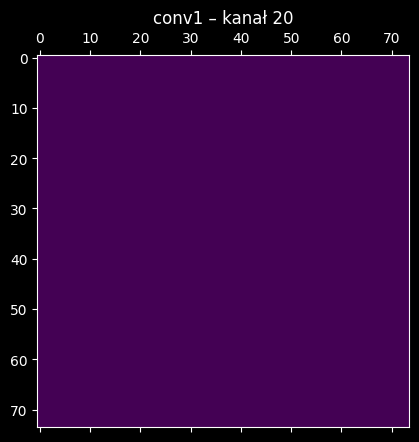

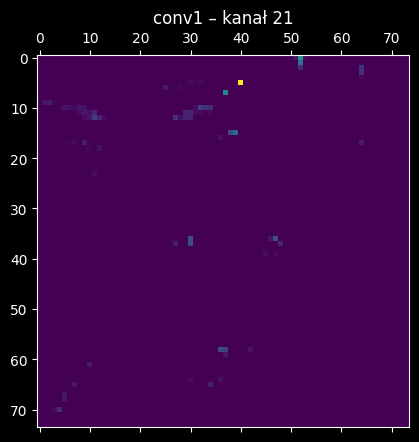

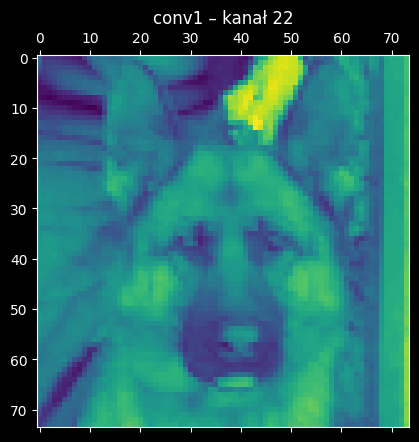

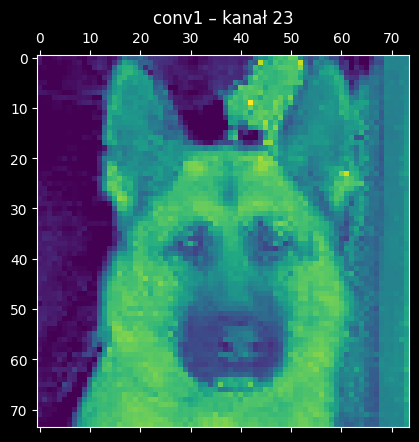

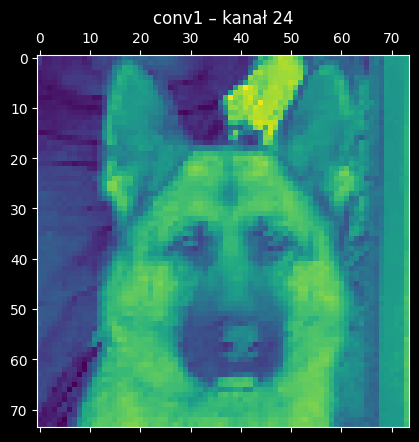

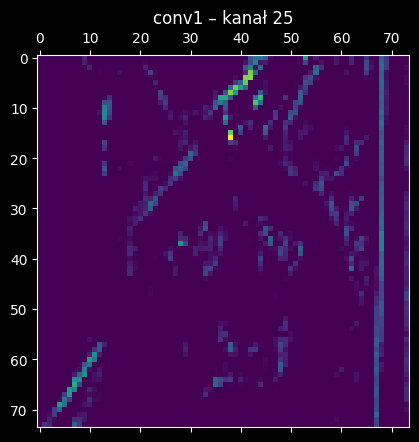

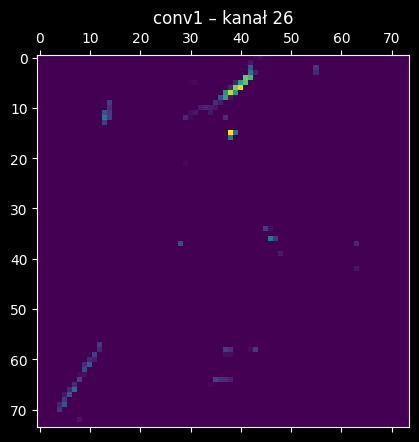

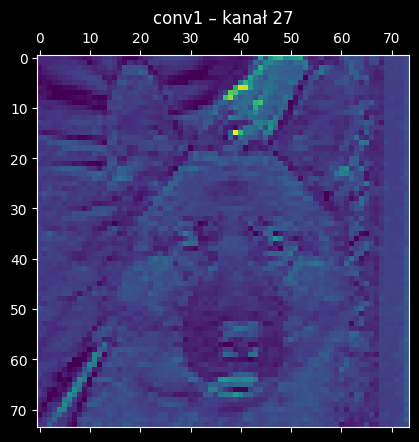

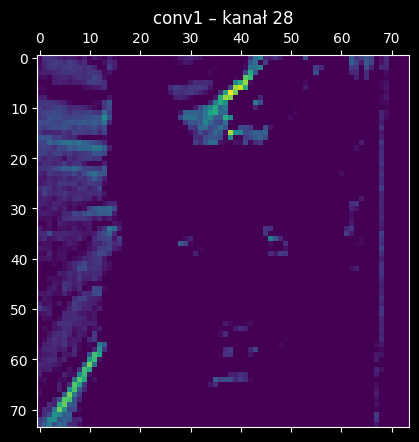

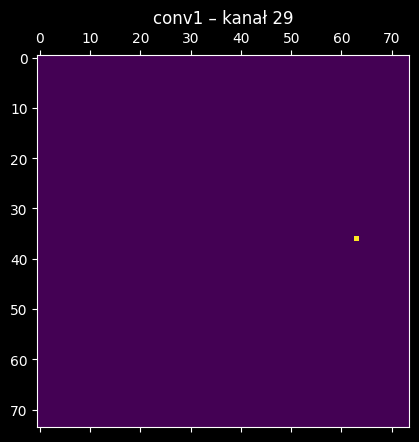

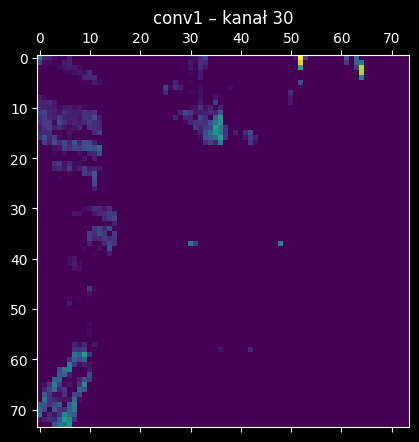

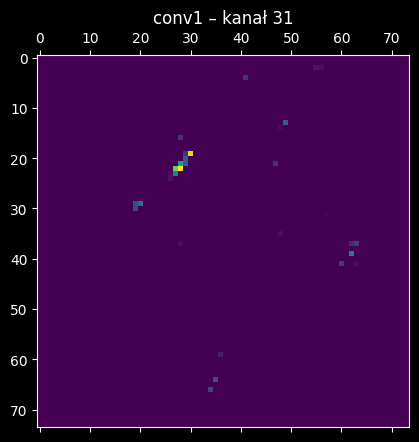

Shape pool1: (1, 72, 72, 64)


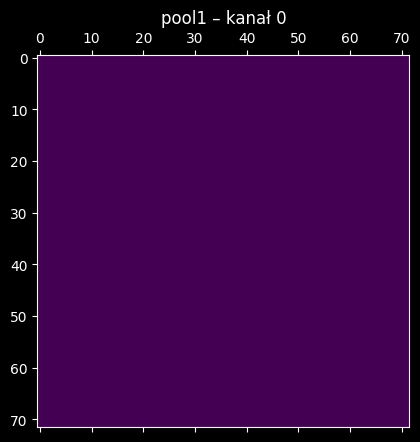

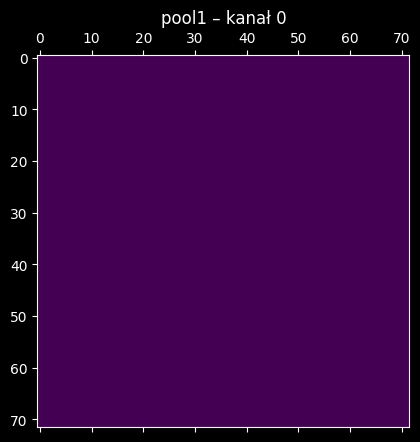

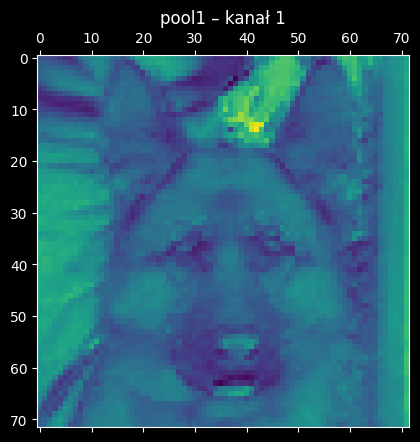

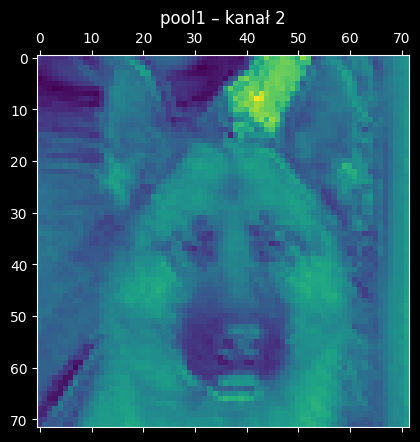

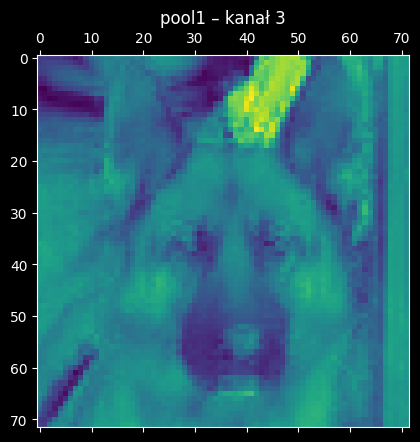

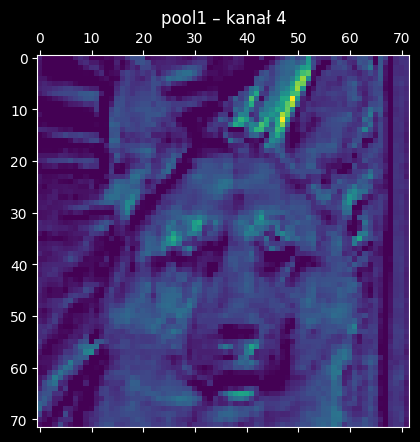

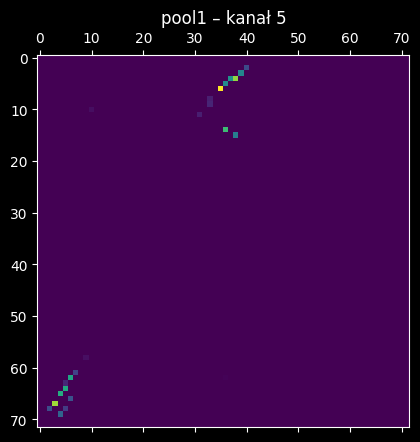

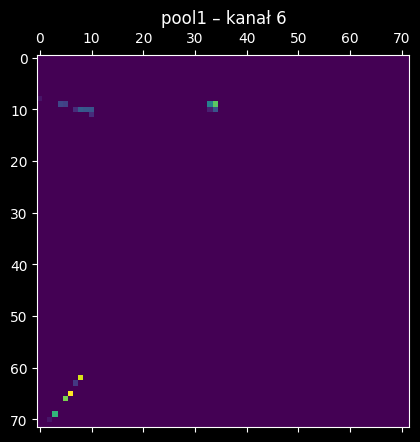

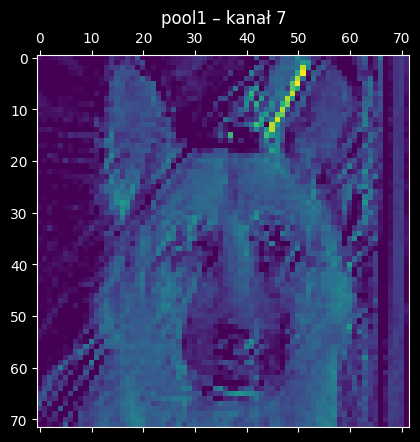

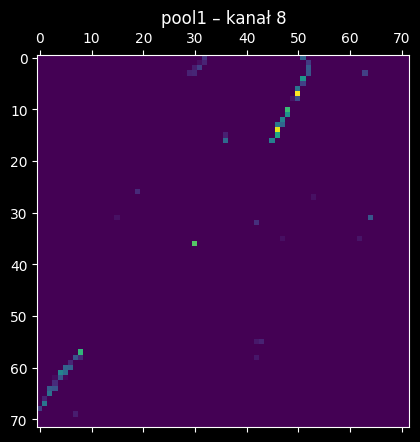

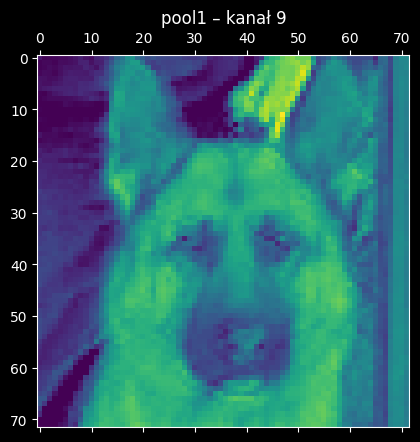

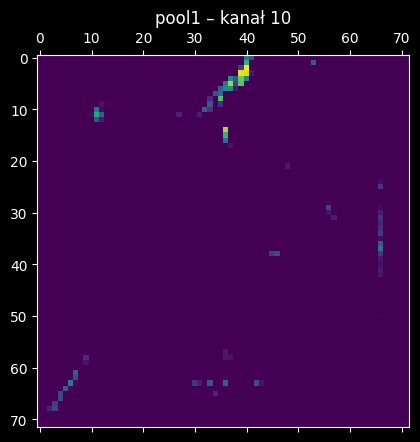

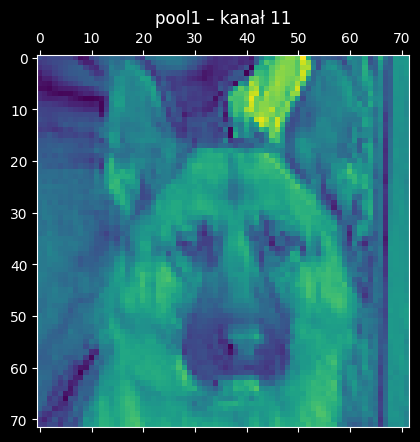

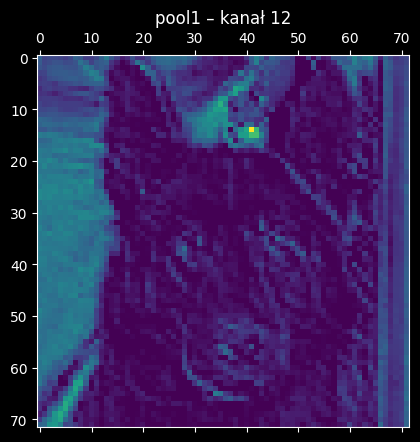

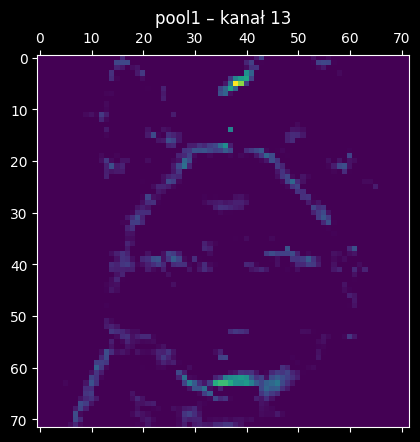

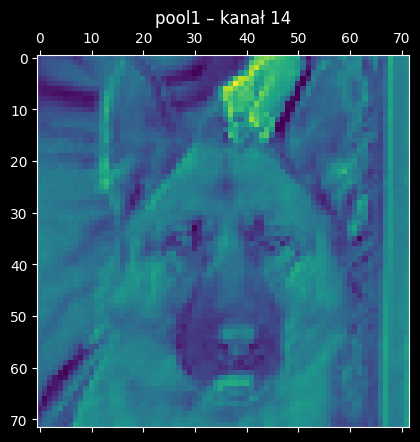

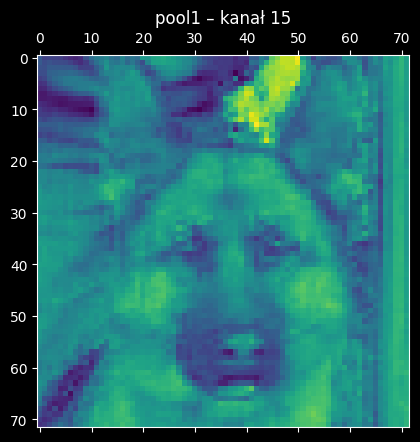

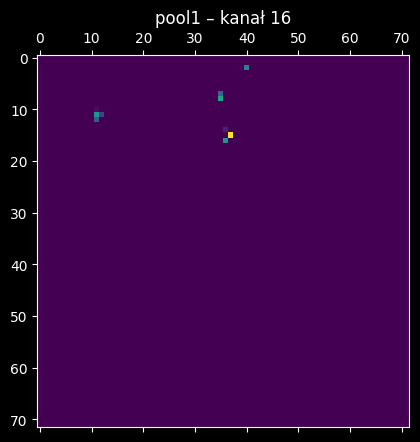

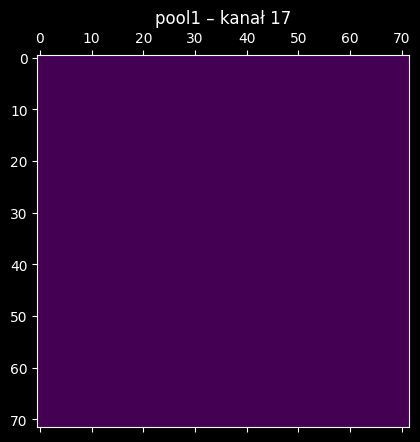

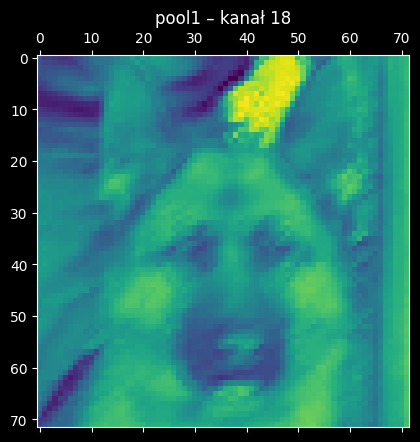

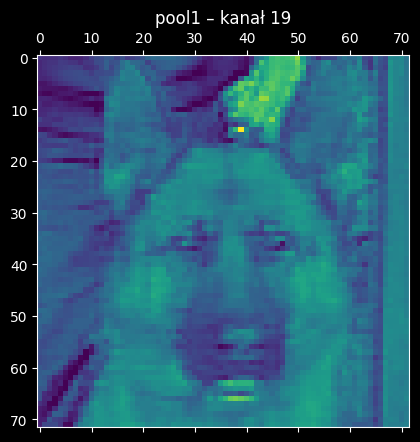

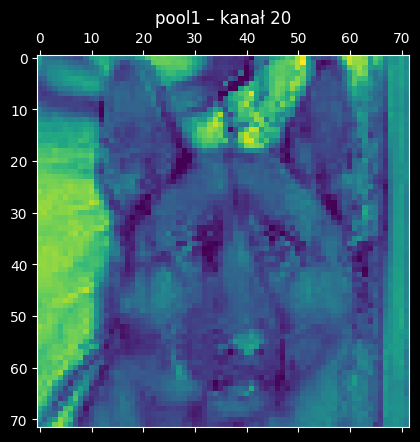

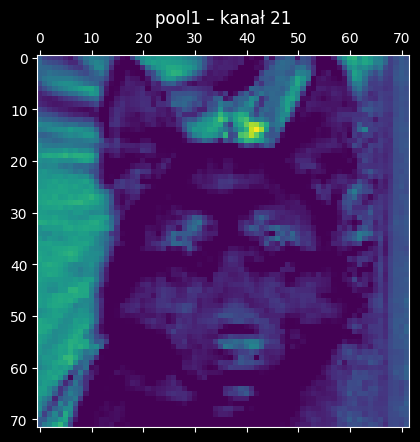

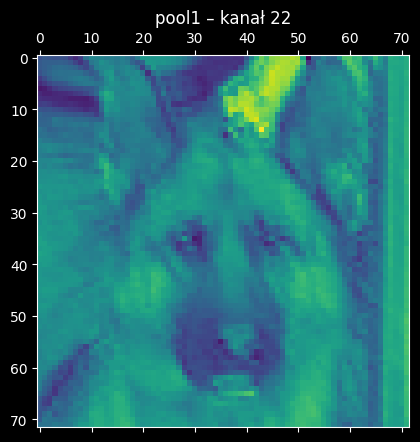

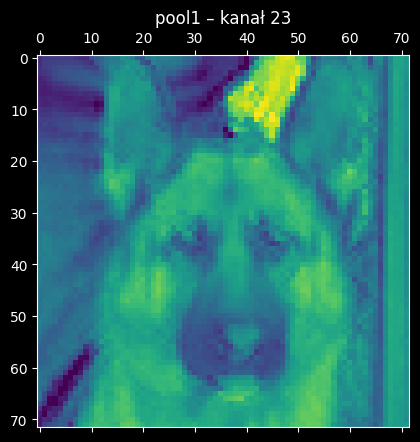

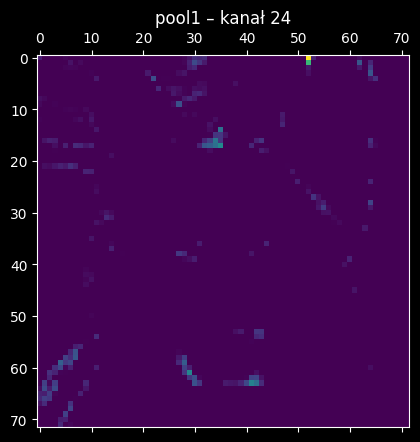

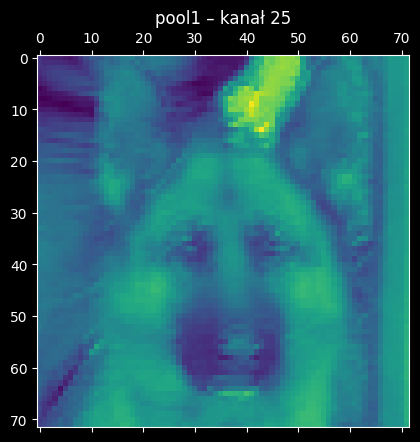

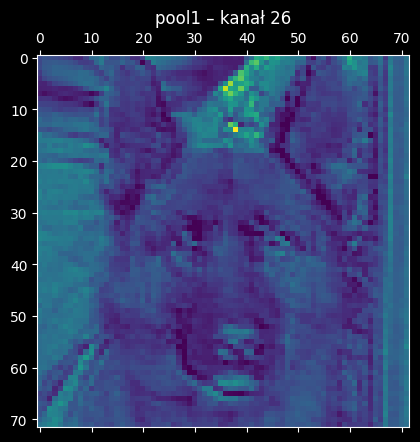

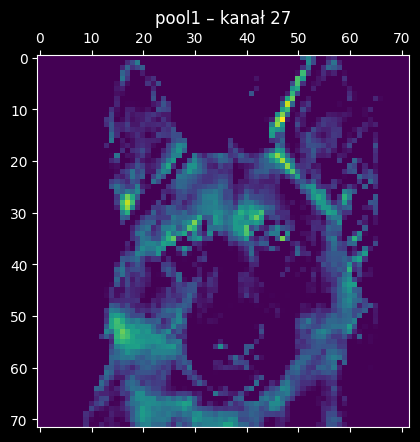

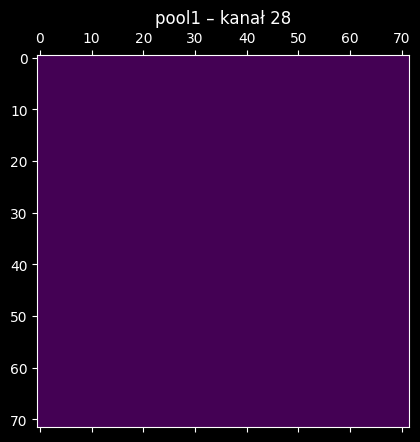

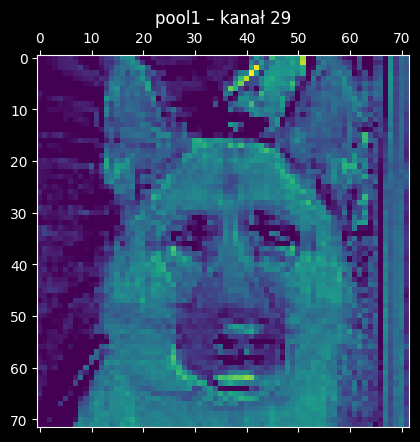

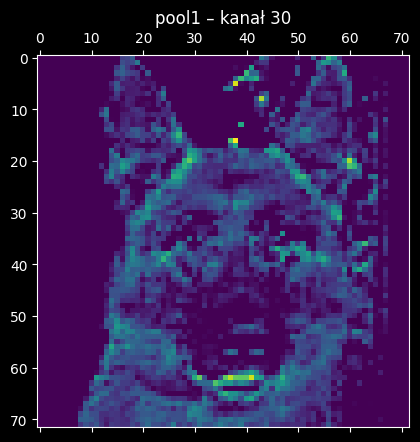

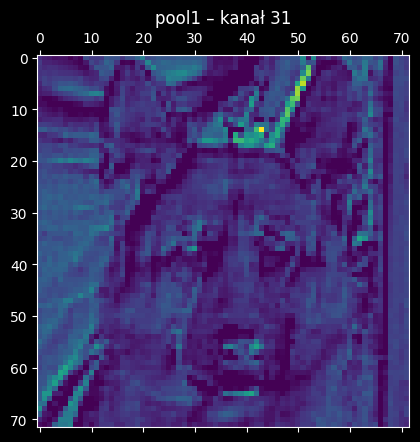

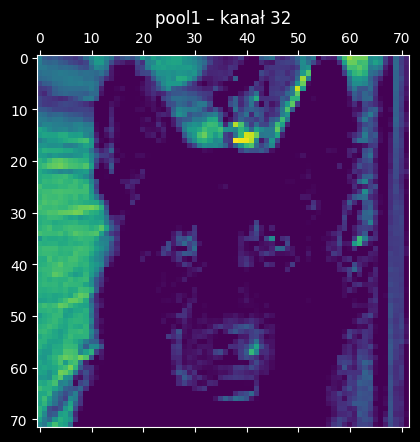

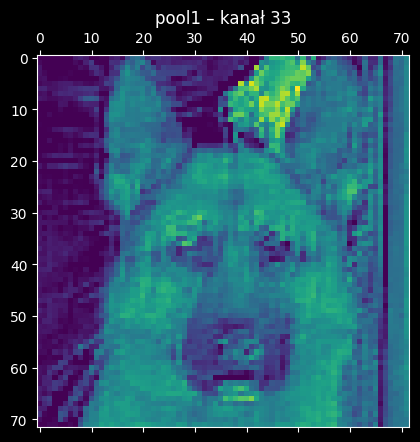

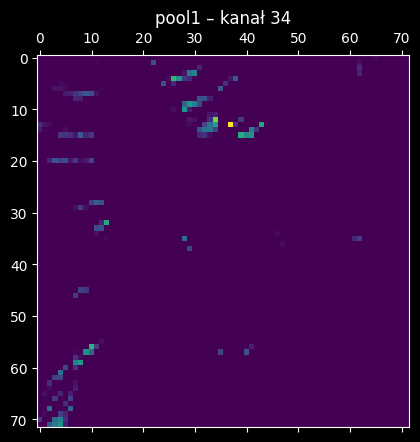

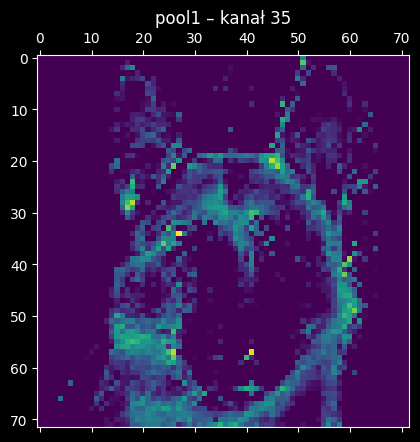

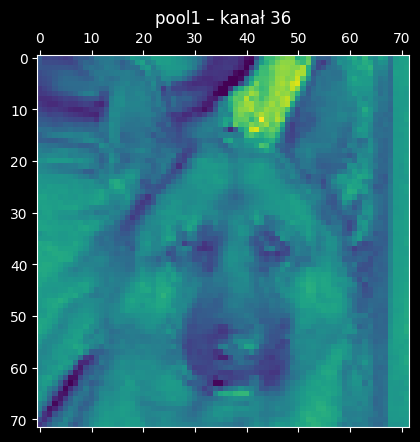

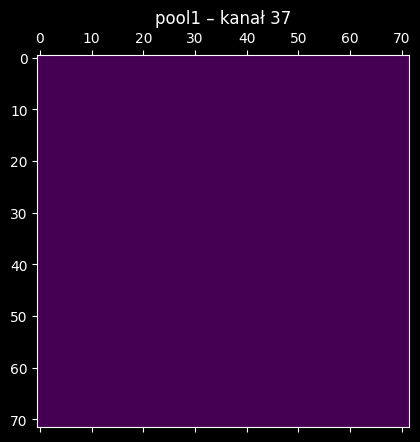

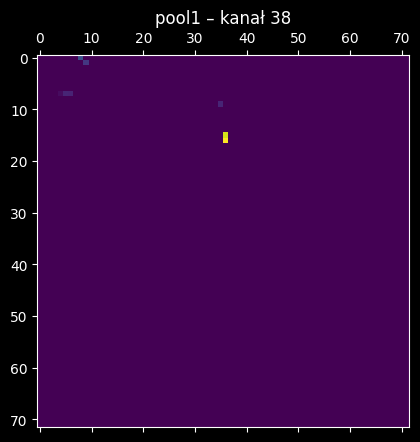

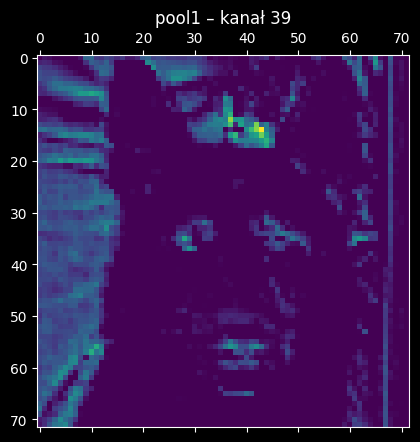

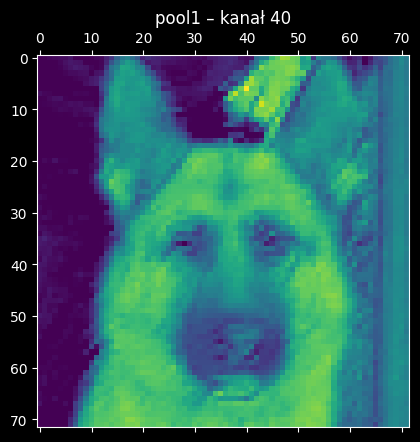

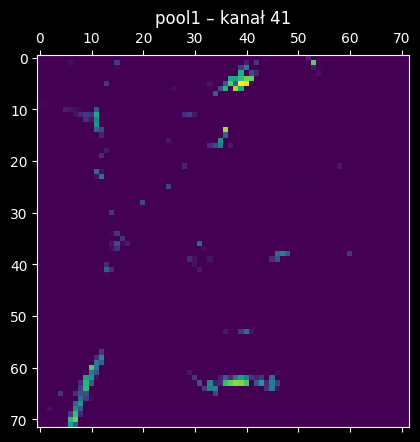

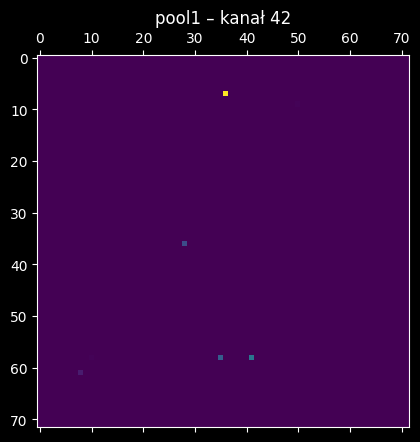

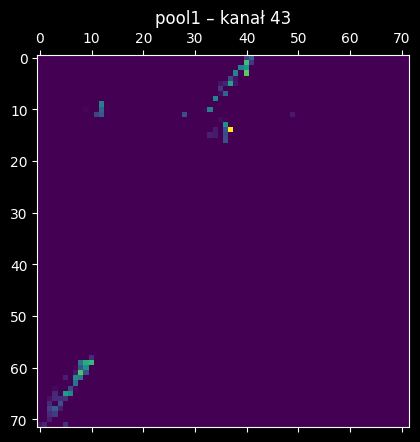

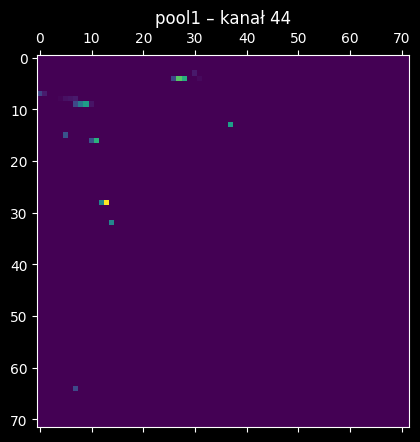

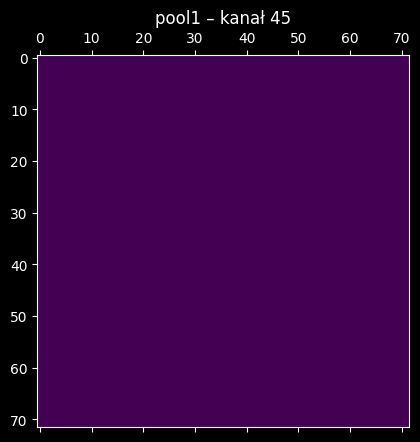

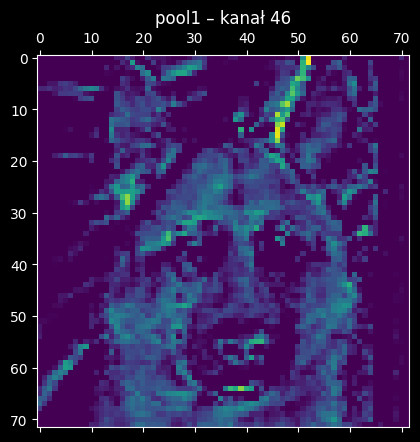

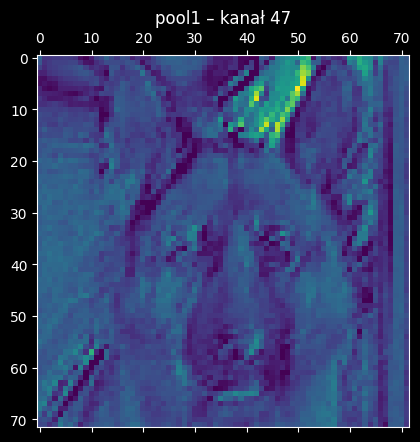

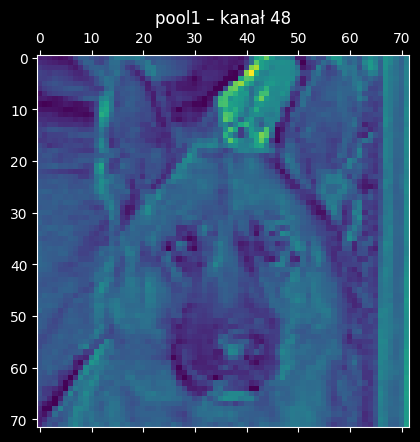

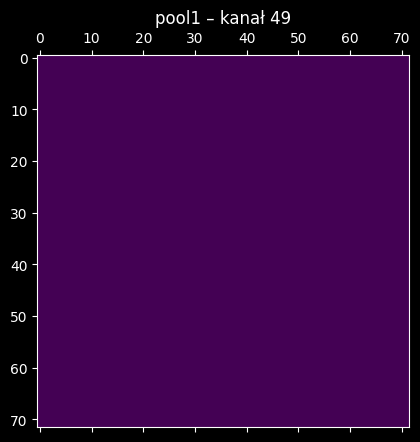

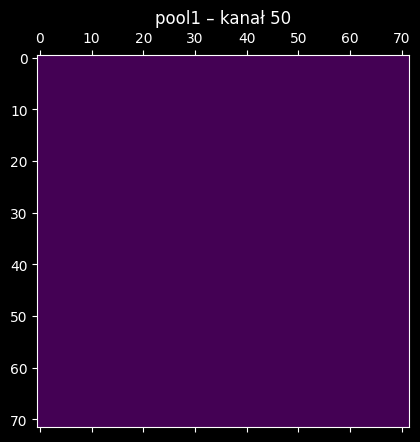

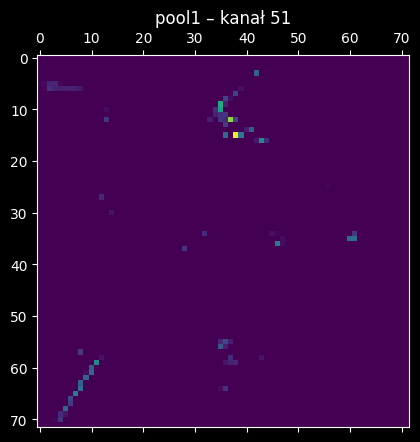

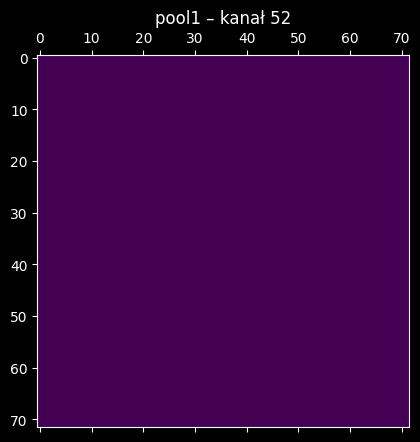

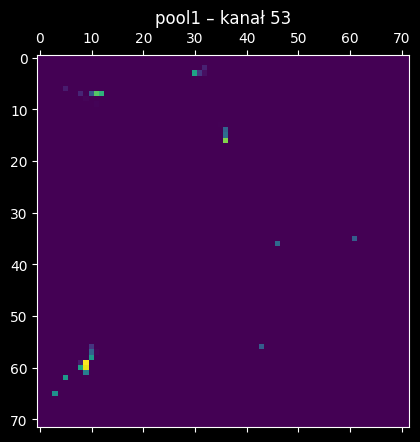

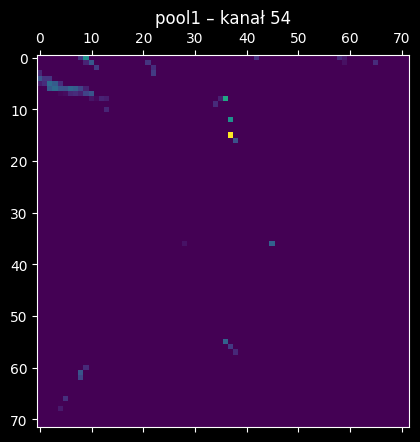

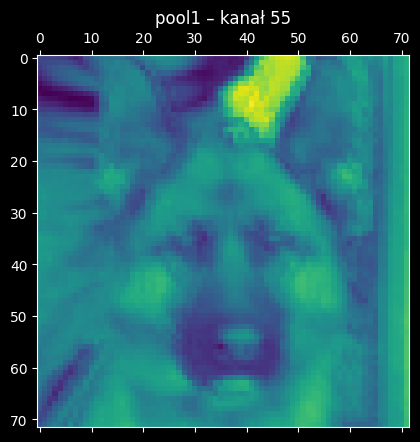

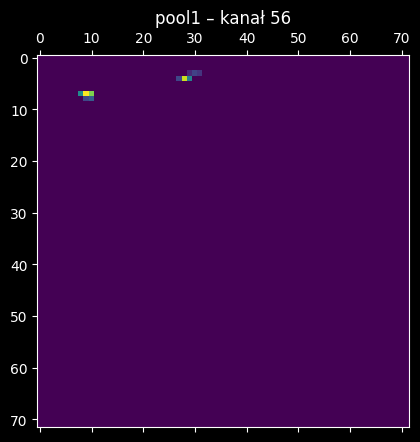

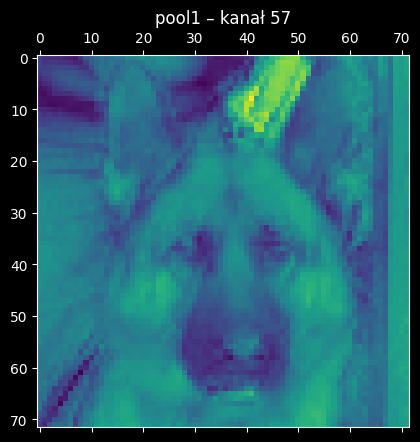

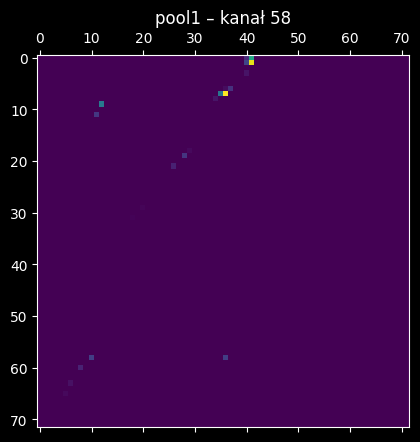

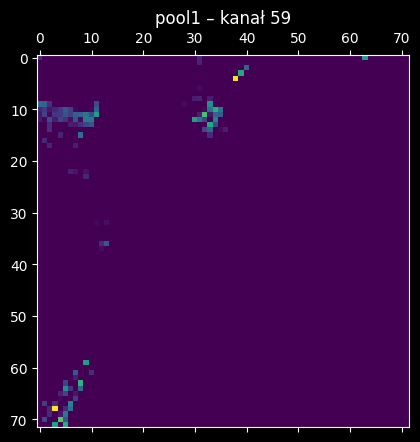

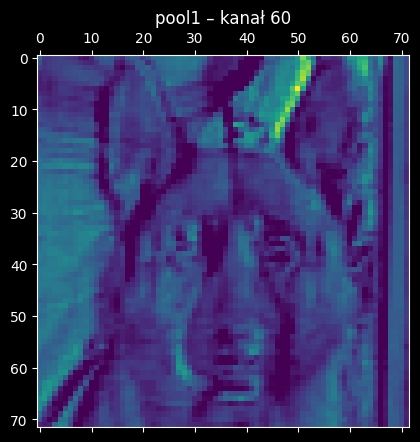

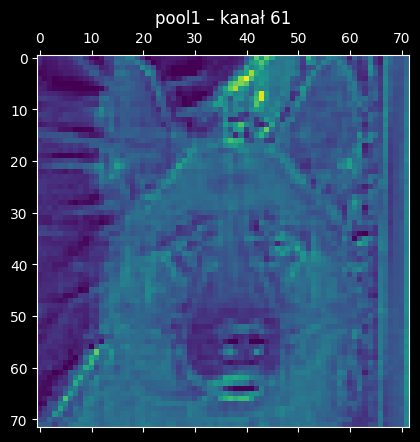

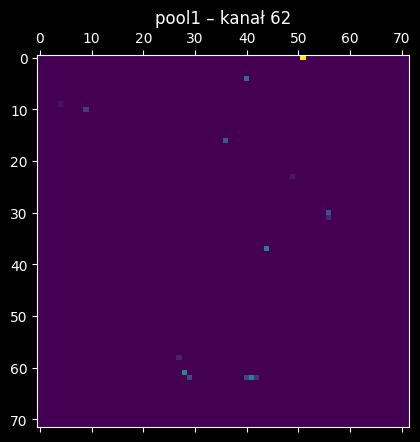

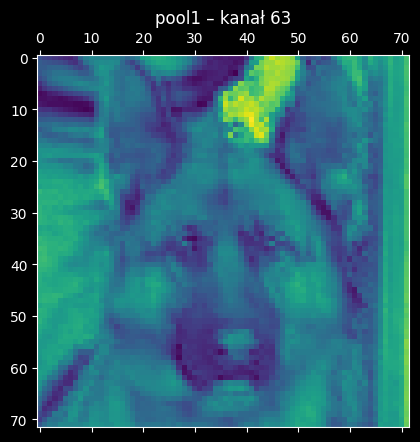

Shape conv2: (1, 36, 36, 64)


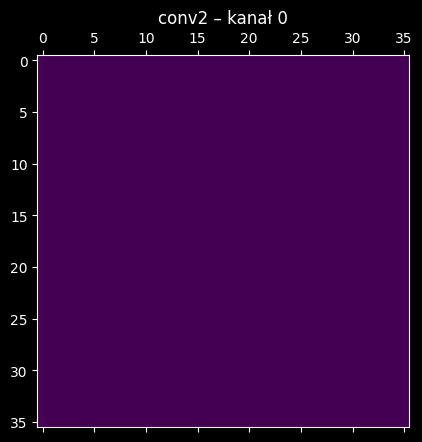

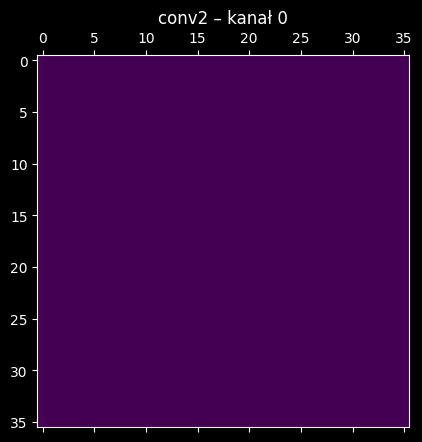

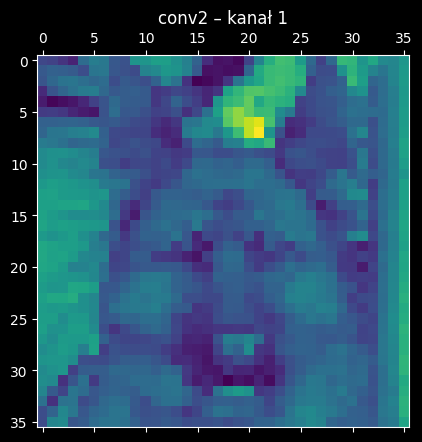

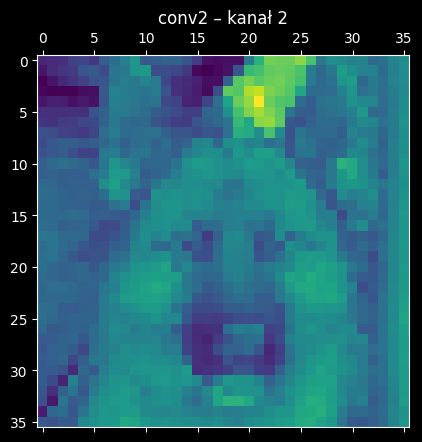

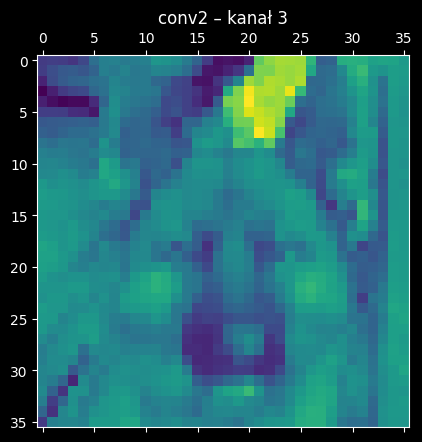

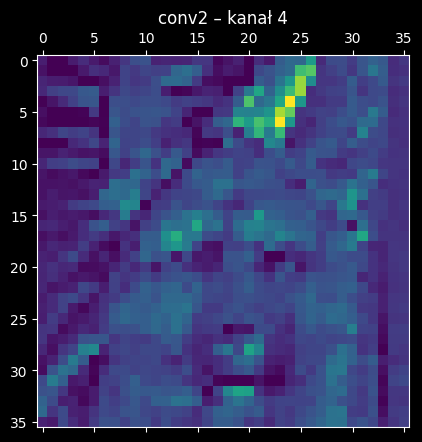

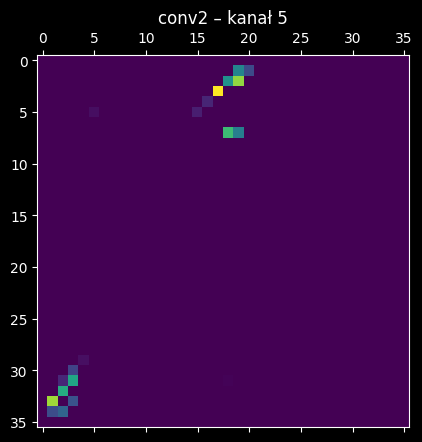

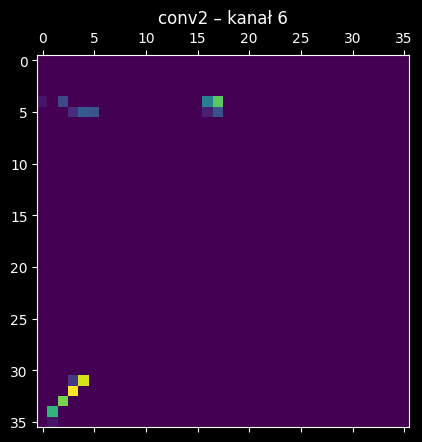

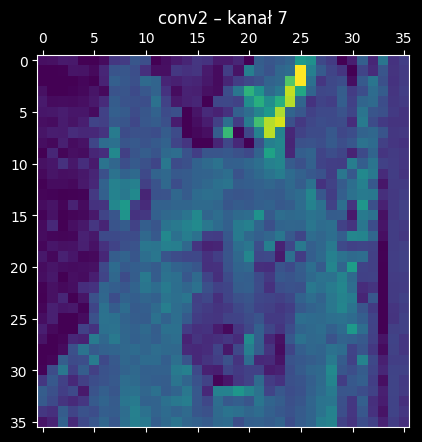

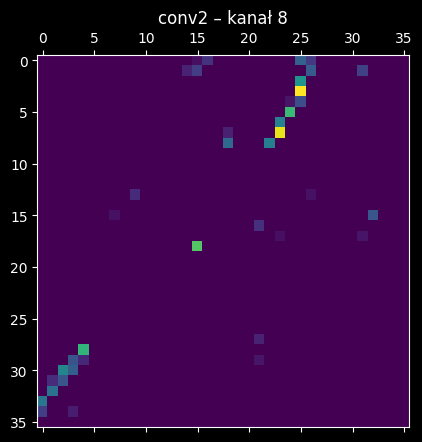

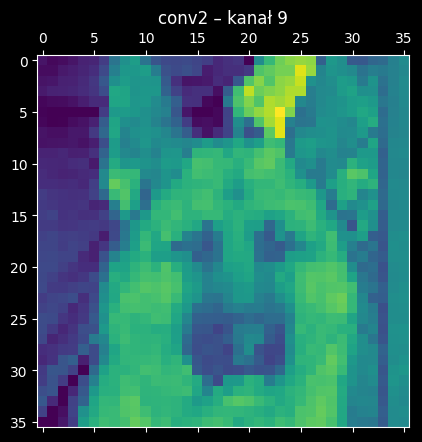

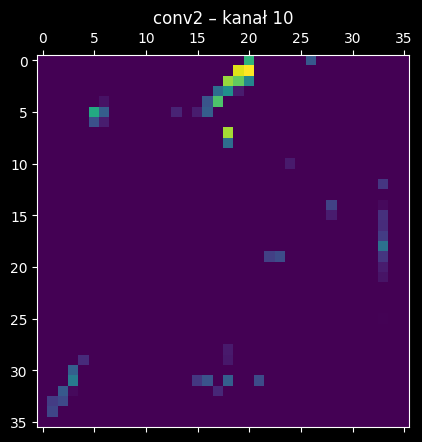

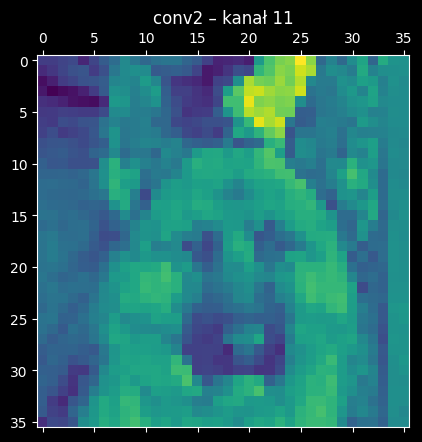

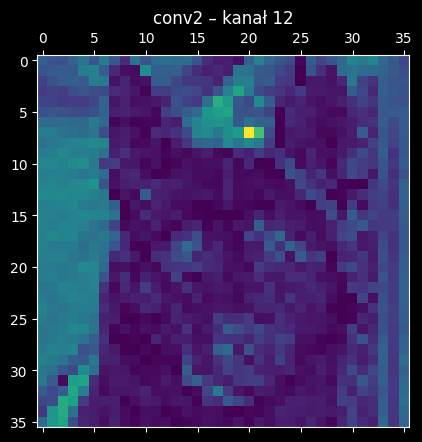

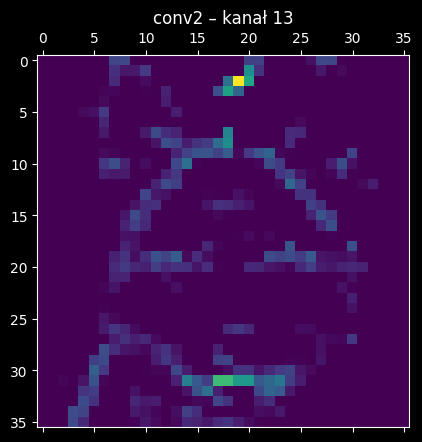

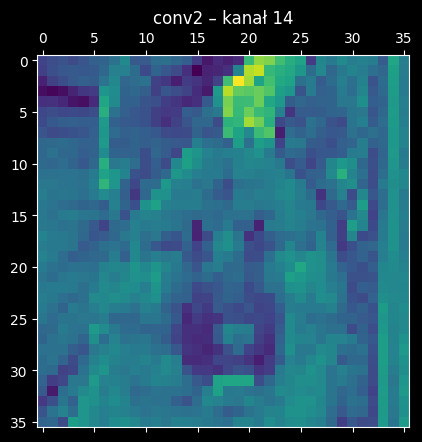

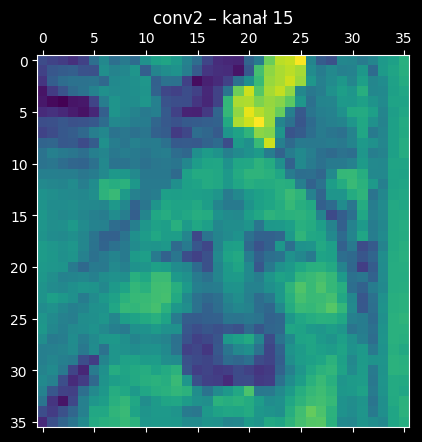

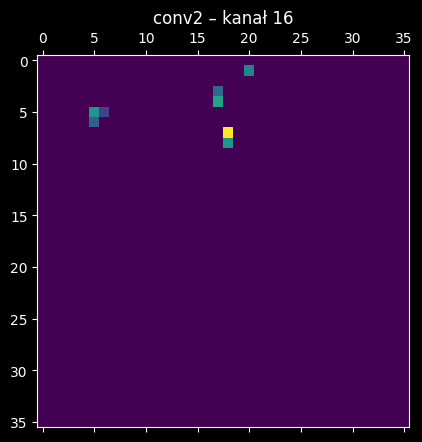

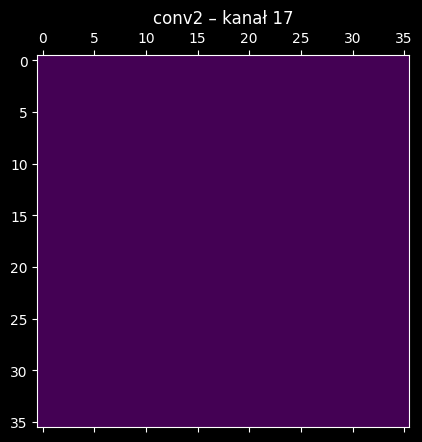

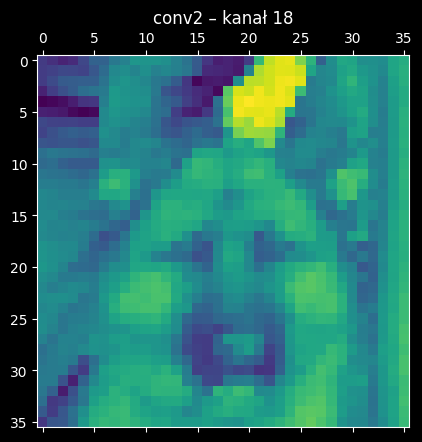

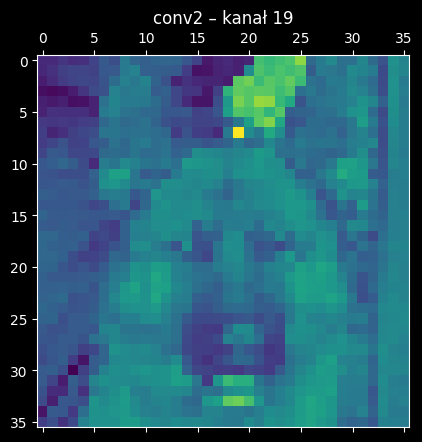

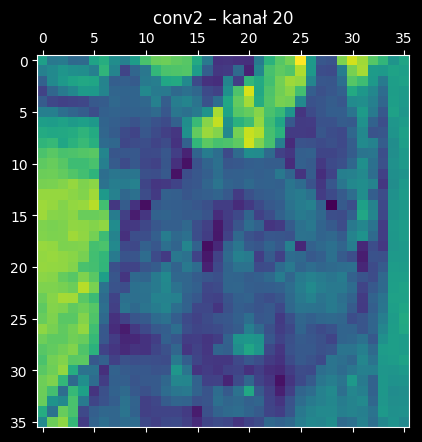

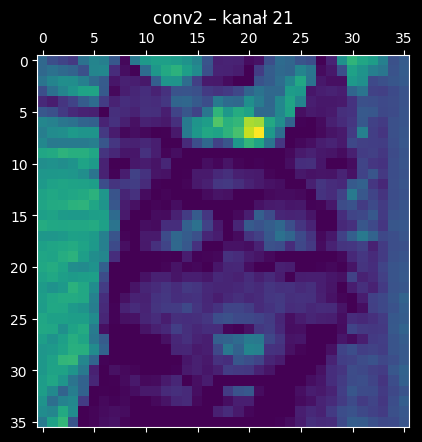

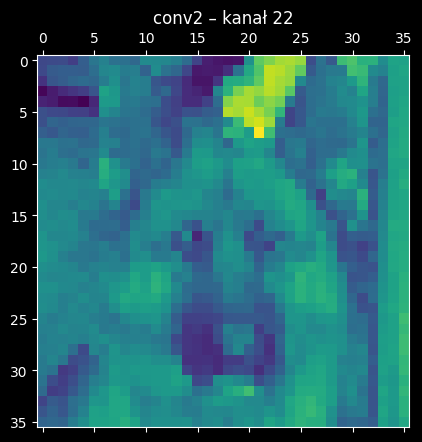

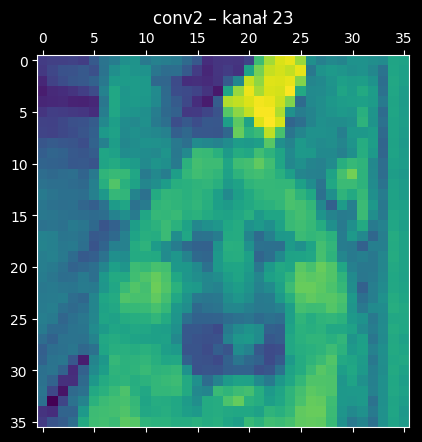

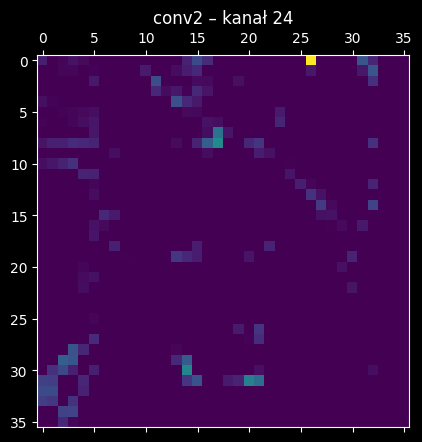

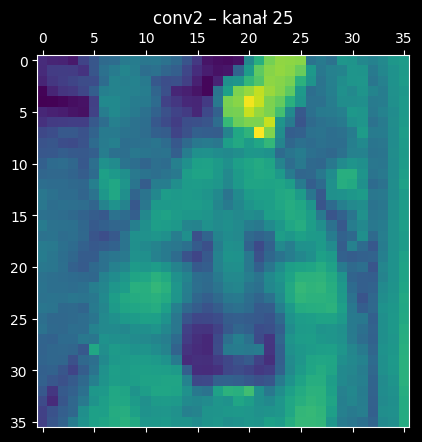

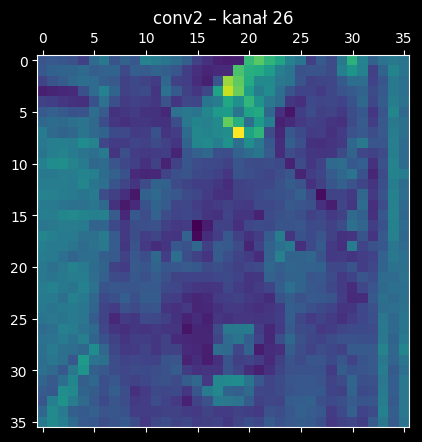

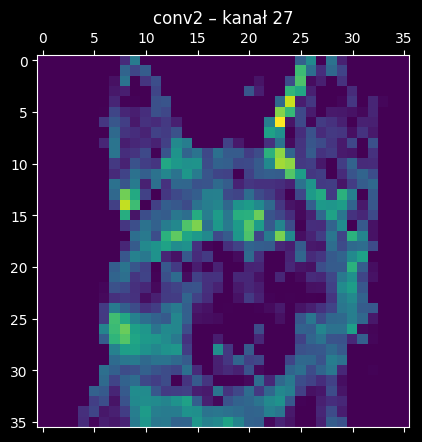

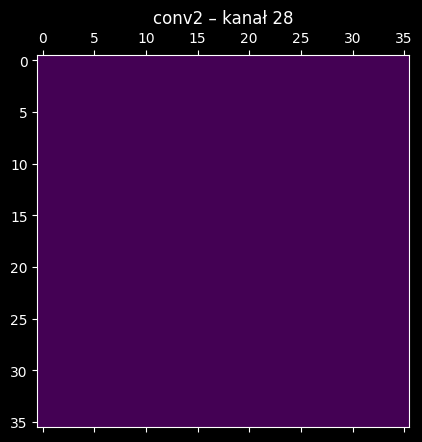

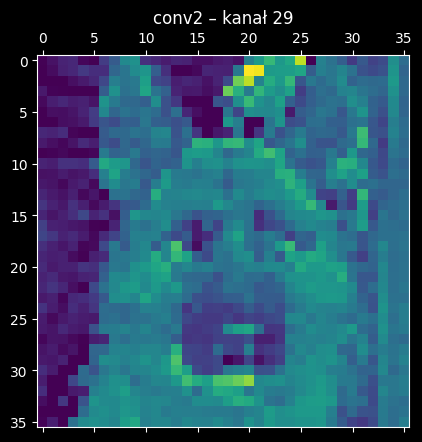

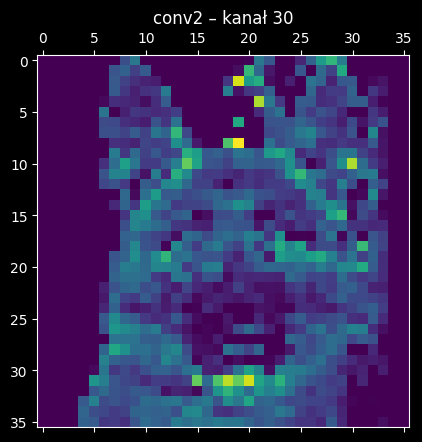

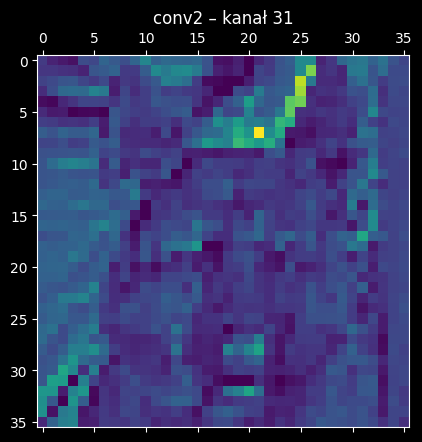

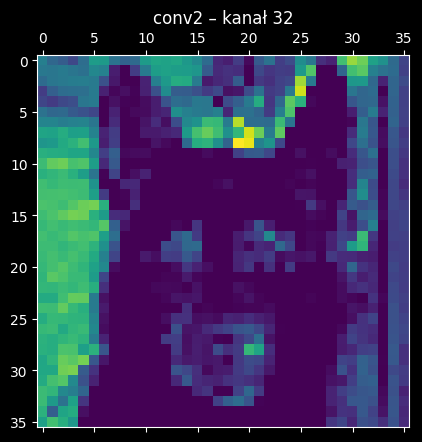

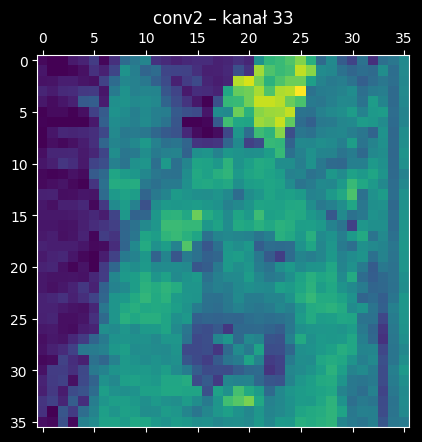

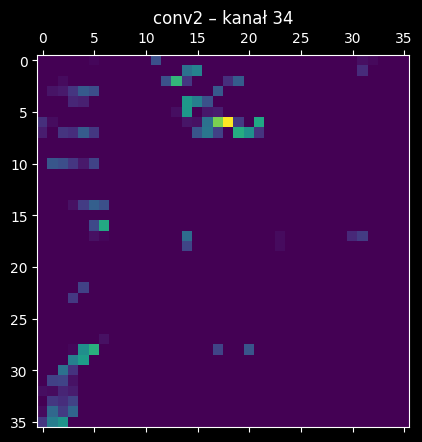

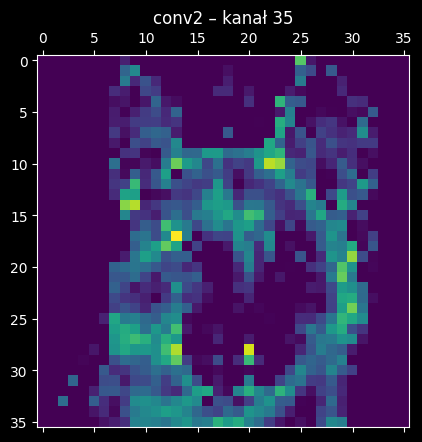

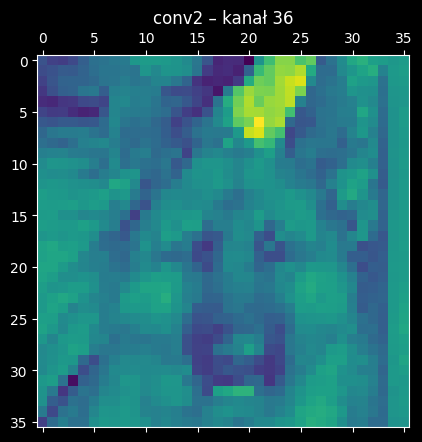

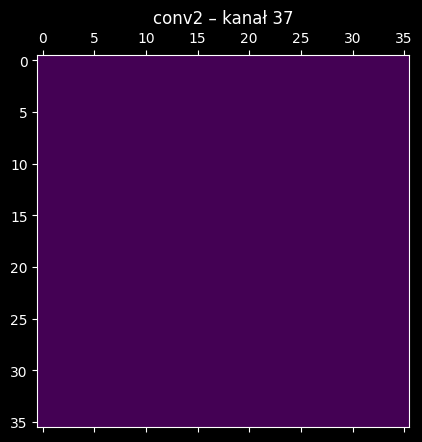

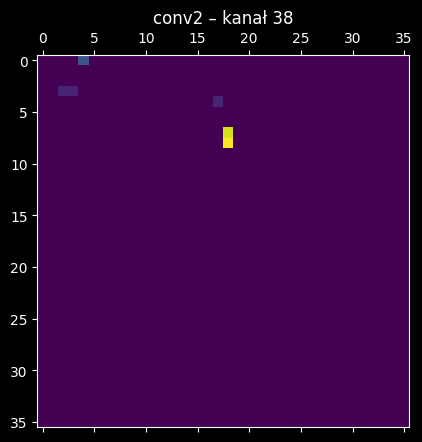

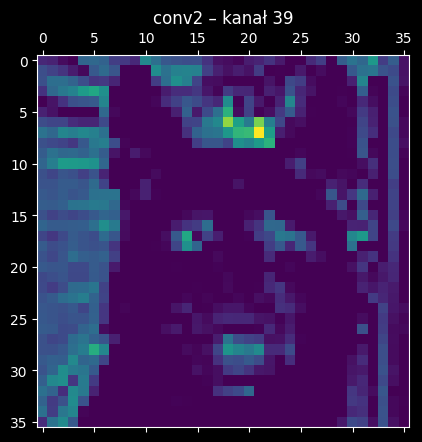

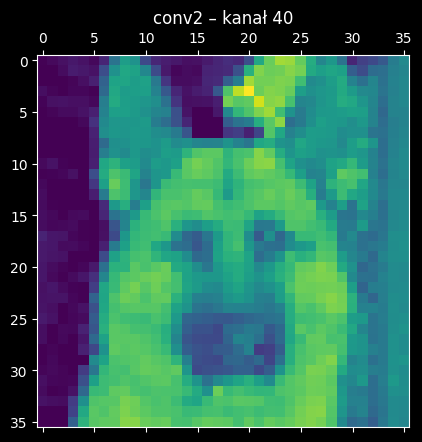

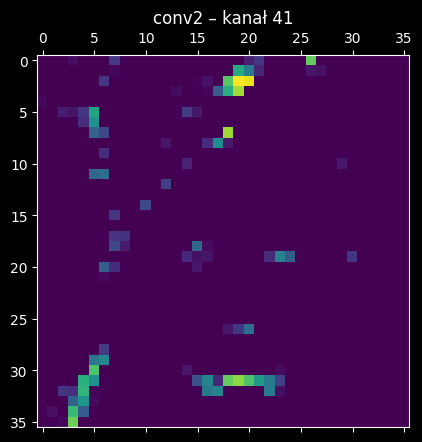

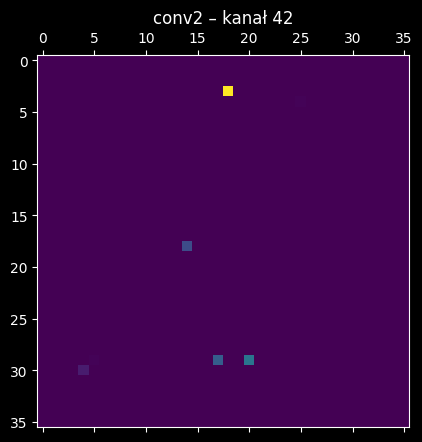

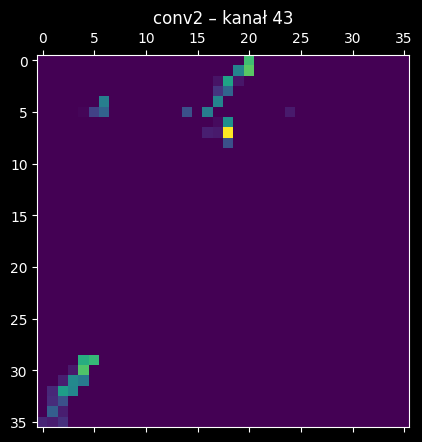

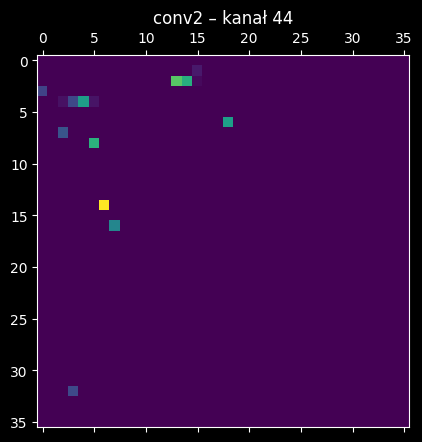

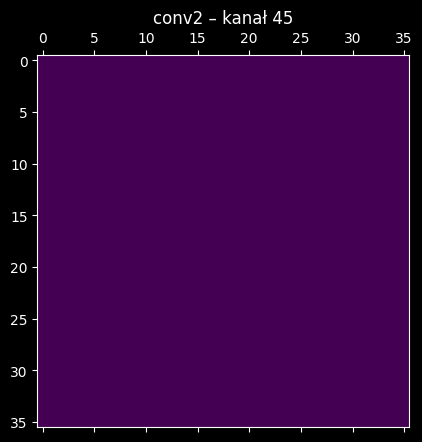

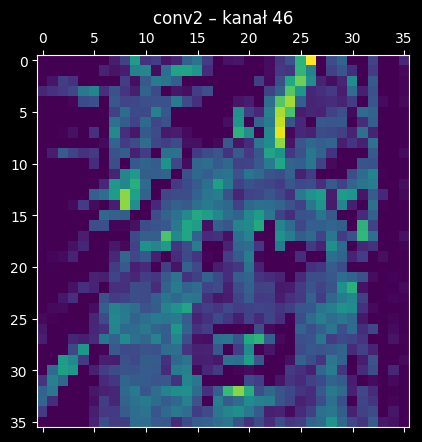

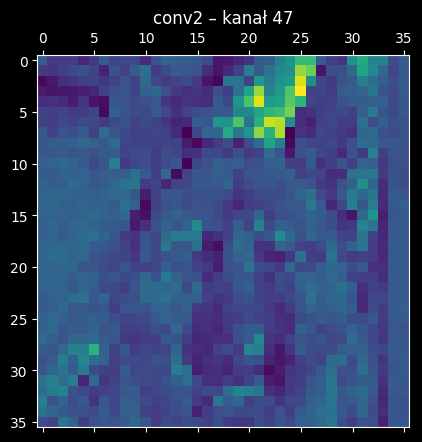

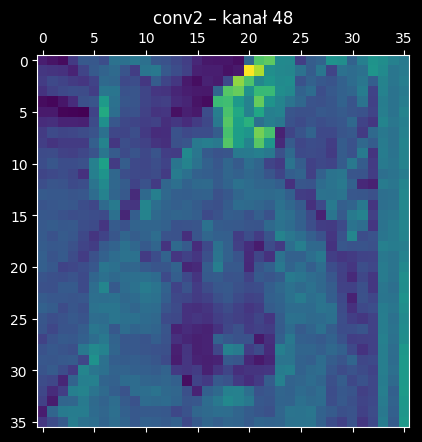

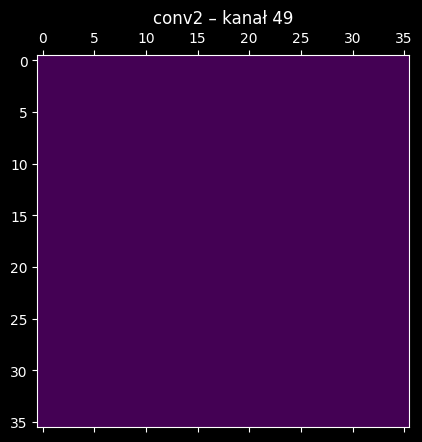

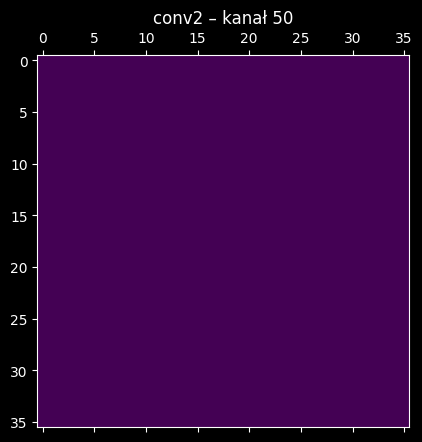

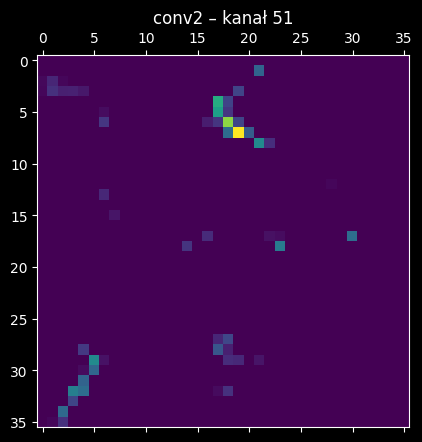

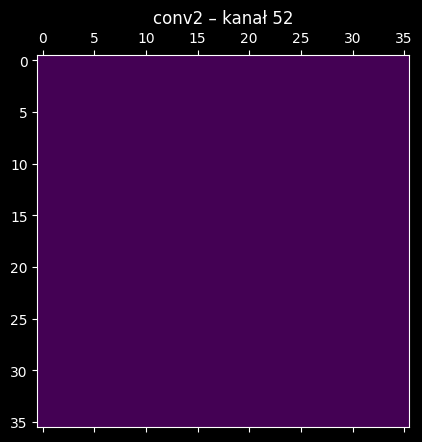

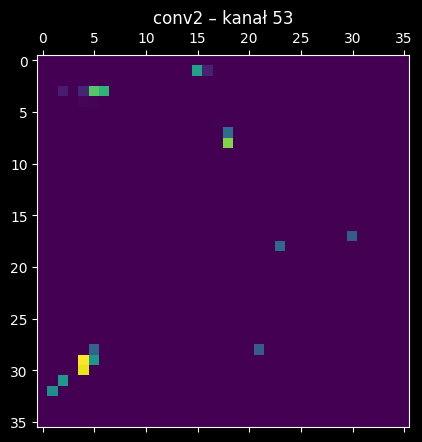

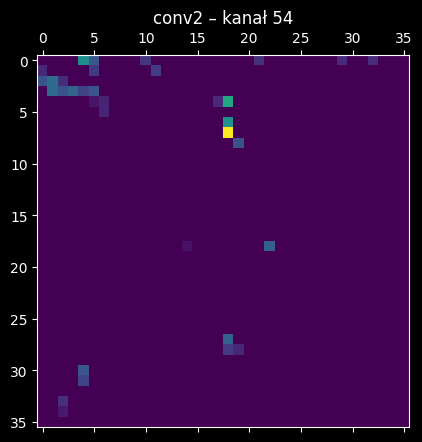

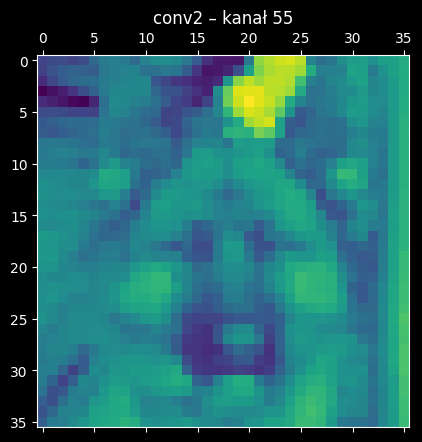

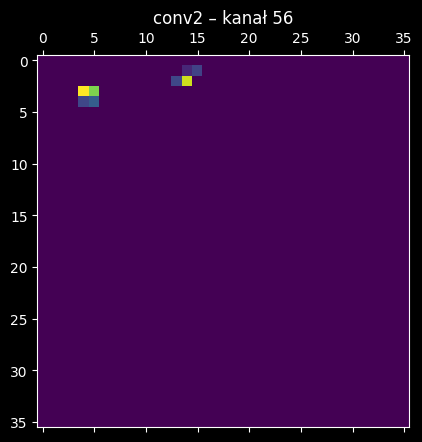

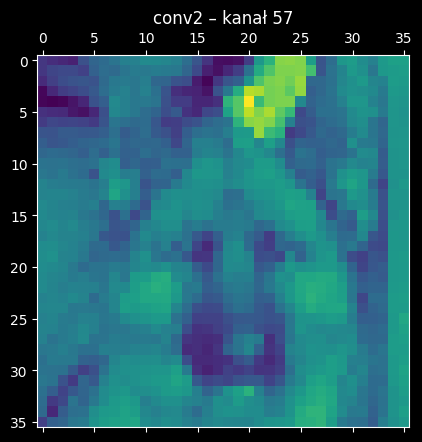

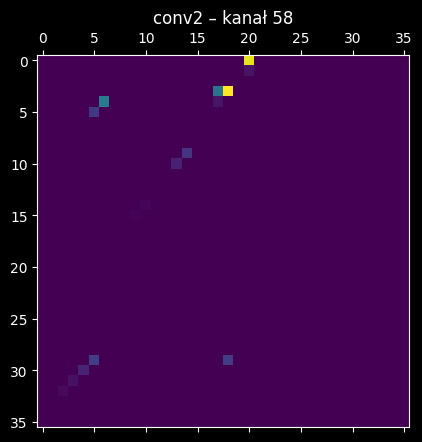

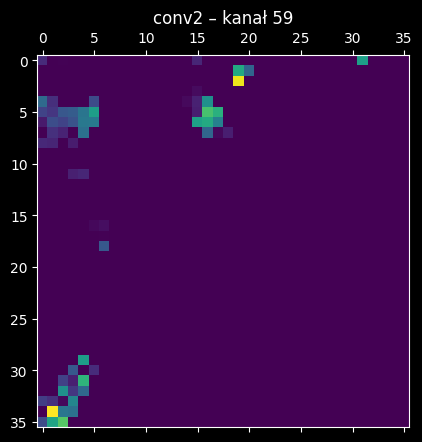

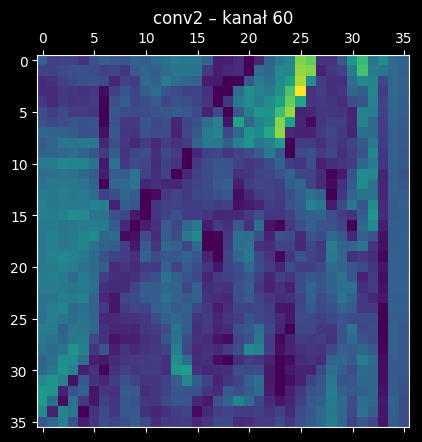

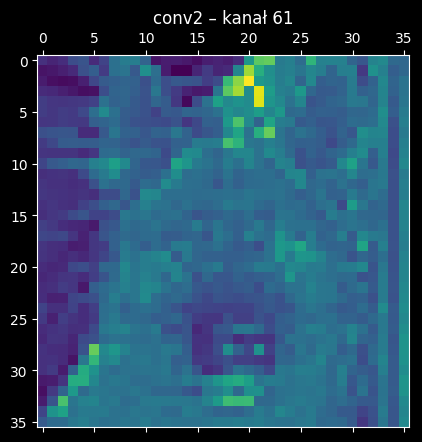

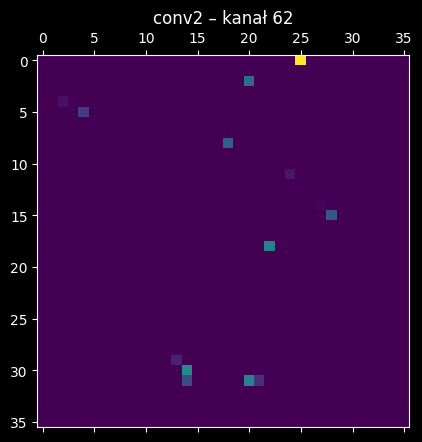

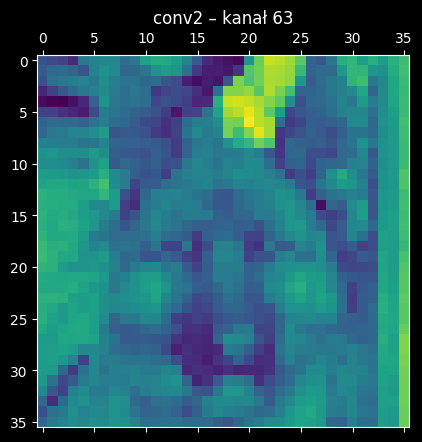

Shape pool2: (1, 34, 34, 128)


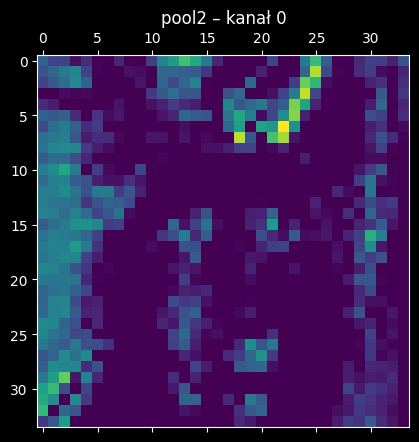

Shape conv3: (1, 17, 17, 128)


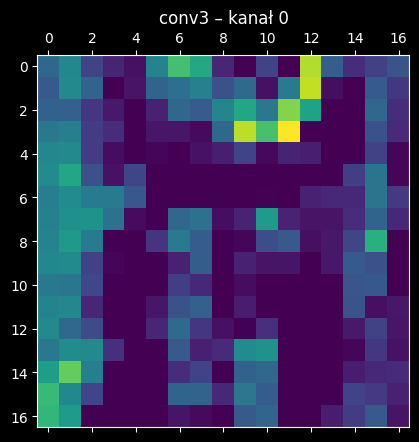

Shape pool3: (1, 15, 15, 128)


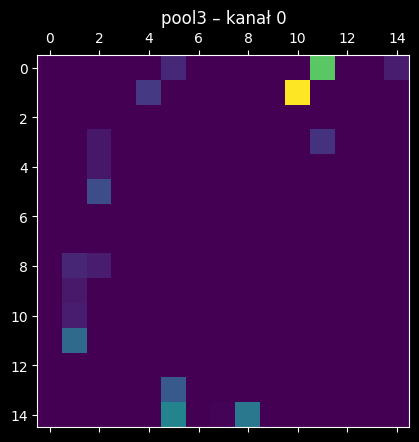

Shape conv4: (1, 7, 7, 128)


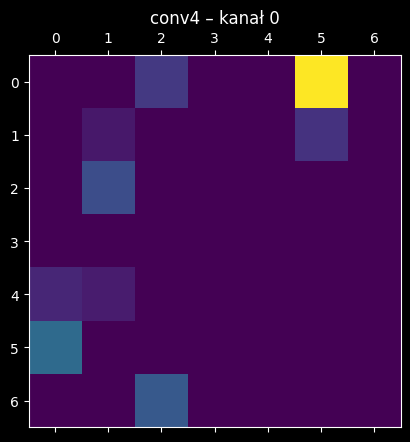

In [26]:
layer_names = ['conv1', 'pool1', 'conv2', 'pool2', 'conv3', 'pool3', 'conv4', 'pool4']

for layer_name, layer_activation in zip(layer_names, activations[1:]):
    print(f'Shape {layer_name}:', layer_activation.shape)

    n_cols = layer_activation.shape[-1]

    plt.matshow(layer_activation[0, :, :, 0], cmap='viridis')
    plt.title(f'{layer_name} – kanał 0')
    plt.show()

    if n_cols <= 64:
        for i in range(n_cols):
            plt.matshow(layer_activation[0, :, :, i], cmap='viridis')
            plt.title(f'{layer_name} – kanał {i}')
            plt.show()